In [1]:
#--------------------------- 
#  環境設定
#--------------------------- 
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # ★これを追加
from IPython.display import display

# 作業ディレクトリを切り替える
os.chdir('/Users/imaihiroshi/Documents/WORK/Programing/Python/narative_experiment')

# 日本語フォント設定（Mac の場合は "Hiragino Sans" が一般的）
font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc"
jp_font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = jp_font.get_name() # 内部フォント名を取得して設定
# 出力時にフォントをTrueTypeにする
plt.rcParams['pdf.fonttype'] = 42   # 42がTrueTypeを意味するらしい。
plt.rcParams['ps.fonttype'] = 42

# Matplotlib の描画スタイルを「ggplot風」に切り替える
plt.style.use("ggplot")

# ワーニングを強制的に消す
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

#--------------------------- 
#  定数と関数定義
#--------------------------- 

# カンマや通貨記号を除去して int に変換する関数
def clean_numeric(series):
    return (
        series.astype(str)
        .str.replace(r'[,\s¥￥円]', '', regex=True)
        .astype(int)
    )

def plot_histogram(df, column_name):
    plt.hist(df[column_name], bins=30, color='blue', edgecolor='black')
    plt.title(f'Histogram of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

#------------------------------------- 
#  ファイルの読み込みとデータフレームへの格納
#------------------------------------- 
#CSV_FILE = './data/csv/Data_20250925.csv'
CSV_FILE = './data/csv/20251104_NonWire.csv'
df = pd.read_csv(CSV_FILE)

#--------------------------- 
#  上代データの数値変換
#--------------------------- 
df["上代数値"] = clean_numeric(df["上代"])

#  分析前のデータを df_originalとして保存しておく
df_original = df

In [4]:
# ==============================================================================
# 変数選択の設定パネル
# ==============================================================================
# dfに存在する全ての変数名が、デフォルト値「1 (使う)」で自動的に設定されます。
# 分析に使わない変数の値だけを「0」に書き換えてください。

variable_selector = {
    '品番': 1,
     'img_file_Name': 0,
     '名前': 0,
     'ブランド名': 0,
     'チャネル': 0,
     '上代': 0,
     '年度': 0,
     '会期月': 0,
     'シーズン': 1,
     'ステップ': 0,
     'ワイヤー': 0,
     'タイプ': 1,
     'シーン1': 1,
     'シーン2': 1,
     '補整力': 1,
     'シルエット': 1,
     '着用感': 0,
     '上代数値': 0,
}


# ---------------------------------------------------------
# dfを更新する処理 variable_selectorで値が1になっている変数名だけをリストとして抽出
selected_columns = [column for column, keep in variable_selector.items() if keep == 1]

# 元のdfを上書きする df_originalはそのまま
df = df[selected_columns]

print("✔ 更新完了！")
df

✔ 更新完了！


,品番,シーズン,タイプ,シーン1,シーン2,補整力,シルエット
0,BT09501,夏,一般,見せる,日中,2,自然
1,BT09503,夏,一般,見せる,日中,2,自然
2,CA525301,通年,一般,見せる,日中,3,高さ/自然
3,CA525104,通年,一般,見せる,日中,3,高さ/自然
4,CA526101,夏,一般,見せる,日中,3,高さ/自然
...,...,...,...,...,...,...,...
81,YH524101,通年,一般~グラマー,見せない,日中,2,自然
82,YH524301,通年,一般~グラマー,見せない,日中,2,自然
83,YH525101,通年,一般~グラマー,見せない,日中,2,自然
84,YH525301,通年,一般~グラマー,見せない,日中,2,自然


## 🍀Medoid得点の説明
以下で算出しているMedoid得点は、クラスタ内の他の点との総距離が最も小さい点で、

$m_k = \arg\min\limits_{i \in C_k} \sum\limits_{j \in C_k} d(x_i, x_j)$

ここで$k$ はクラスタ番号で、medoid_score[i] = データ点 i が属するクラスタの medoid からの距離

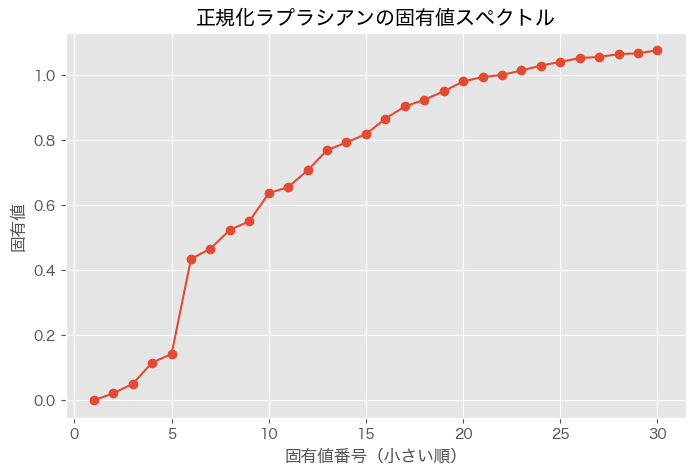

最初の20個の固有値: [-0.        0.021214  0.050293  0.115748  0.141799  0.434446  0.465963
  0.523708  0.550106  0.636012  0.655509  0.706396  0.768713  0.792668
  0.817625  0.865615  0.902959  0.923567  0.949594  0.97995 ]

=== Silhouetteスコアによるクラスタ数評価 ===
クラスタ数 2 : Silhouetteスコア = 0.276
クラスタ数 3 : Silhouetteスコア = 0.295
クラスタ数 4 : Silhouetteスコア = 0.305
クラスタ数 5 : Silhouetteスコア = 0.354
クラスタ数 6 : Silhouetteスコア = 0.365
クラスタ数 7 : Silhouetteスコア = 0.390
クラスタ数 8 : Silhouetteスコア = 0.432
クラスタ数 9 : Silhouetteスコア = 0.461
クラスタ数 10 : Silhouetteスコア = 0.478
クラスタ数 11 : Silhouetteスコア = 0.484
クラスタ数 12 : Silhouetteスコア = 0.483
クラスタ数 13 : Silhouetteスコア = 0.504
クラスタ数 14 : Silhouetteスコア = 0.516
クラスタ数 15 : Silhouetteスコア = 0.521


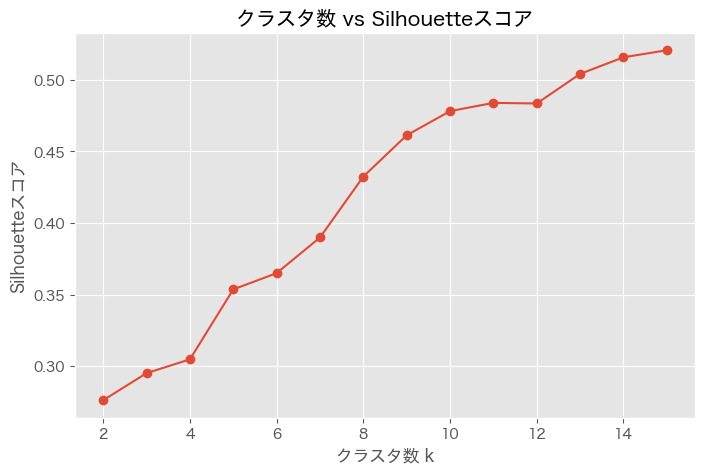

In [9]:
# ==============================================================================
# 何個のクラスタリングが適切かを調べる
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) 分析に使う変数の指定（先頭列＝品番を除外して残り全部） ---
df_cls = df.iloc[:, 1:].copy()  # 列数が変わっても安全

# --- 0) 前処理（数値・カテゴリの自動識別） ---
categorical_features = df_cls.select_dtypes(include=['object', 'category']).columns
numerical_features = df_cls.select_dtypes(include=np.number).columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# df_cls を数値化（疎行列になり得る）
X_processed = preprocessor.fit_transform(df_cls)
# kneighbors_graph に渡せるよう必ず 2D 数値配列へ
X_num = X_processed.toarray() if hasattr(X_processed, "toarray") else np.asarray(X_processed)

# --- 1) 近傍グラフ（affinity） ---
from sklearn.neighbors import kneighbors_graph
n_samples = X_num.shape[0]
n_neighbors = min(10, max(1, n_samples - 1))  # サンプル数に応じて安全に

A = kneighbors_graph(X_num, n_neighbors=n_neighbors, include_self=True, mode='connectivity')
A = 0.5 * (A + A.T)  # 対称化

# --- 2) 正規化ラプラシアン ---
from scipy.sparse import csgraph
L = csgraph.laplacian(A, normed=True)

# --- 3) 固有値計算（小さいものから） ---
from scipy.sparse.linalg import eigsh
k_eigs = min(30, max(2, n_samples - 1))
w, _ = eigsh(L, k=k_eigs, which='SM')  # Smallest Magnitude
eigenvalues = np.sort(np.real(w))

# --- 4) 可視化 ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title("正規化ラプラシアンの固有値スペクトル")
plt.xlabel("固有値番号（小さい順）")
plt.ylabel("固有値")
plt.grid(True)
plt.show()

print("最初の20個の固有値:", np.round(eigenvalues[:20], 6))

# ==============================================================================
# Silhouetteスコアによるクラスタ適正数評価
# ==============================================================================
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

print("\n=== Silhouetteスコアによるクラスタ数評価 ===")
scores = []
mr = 16
for k in range(2, mr):  # 2〜15クラスタを評価
    sc = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=n_neighbors,
        assign_labels='kmeans',
        random_state=0
    )
    labels = sc.fit_predict(X_num)
    score = silhouette_score(X_num, labels)
    scores.append(score)
    print(f"クラスタ数 {k} : Silhouetteスコア = {score:.3f}")

# --- 折れ線グラフ ---
plt.figure(figsize=(8,5))
plt.plot(range(2, mr), scores, marker='o')
plt.title("クラスタ数 vs Silhouetteスコア")
plt.xlabel("クラスタ数 k")
plt.ylabel("Silhouetteスコア")
plt.grid(True)
plt.show()


重み付け後のデータシェイプ: (86, 6)
適用された重み (sqrt): [1.   1.41 1.   1.22 1.41 1.22]


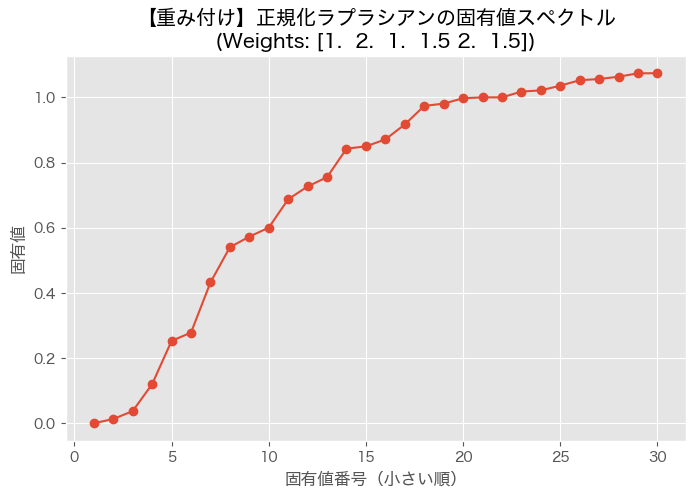

最初の20個の固有値: [-0.        0.012991  0.03726   0.119955  0.25272   0.278058  0.431991
  0.540148  0.57251   0.600169  0.687391  0.726523  0.755048  0.842521
  0.849722  0.870909  0.916946  0.9737    0.980829  0.997295]

=== 【重み付け】Silhouetteスコアによるクラスタ数評価 ===
クラスタ数 2 : Silhouetteスコア = 0.258
クラスタ数 3 : Silhouetteスコア = 0.291
クラスタ数 4 : Silhouetteスコア = 0.378
クラスタ数 5 : Silhouetteスコア = 0.363
クラスタ数 6 : Silhouetteスコア = 0.401
クラスタ数 7 : Silhouetteスコア = 0.421
クラスタ数 8 : Silhouetteスコア = 0.460
クラスタ数 9 : Silhouetteスコア = 0.475
クラスタ数 10 : Silhouetteスコア = 0.498
クラスタ数 11 : Silhouetteスコア = 0.511
クラスタ数 12 : Silhouetteスコア = 0.519
クラスタ数 13 : Silhouetteスコア = 0.555
クラスタ数 14 : Silhouetteスコア = 0.534
クラスタ数 15 : Silhouetteスコア = 0.605


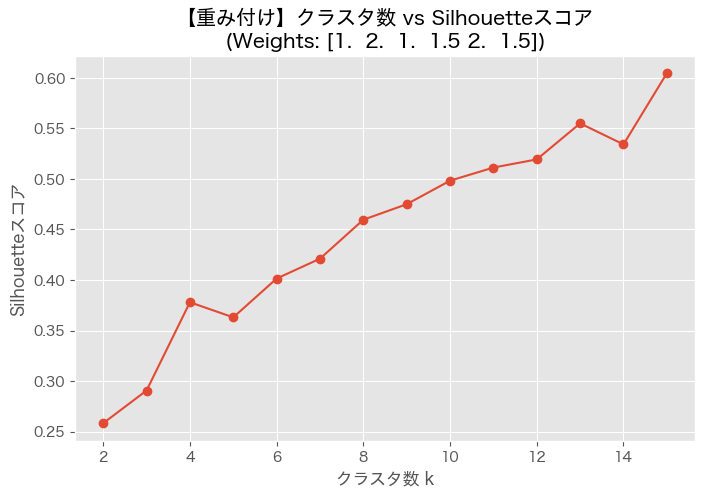

In [5]:
# ==============================================================================
# 　【重み付け対応】クラスタ数評価（固有値スペクトル ＆ Silhouette）
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# --- ① CSV読み込み（元の 'df' をそのまま使用） ---
# (注：このスクリプトの前に、df = pd.read_csv(...) が実行されている前提です)

# --- ② 分析対象の列を定義 ---
# (注：元のdfの列名から、クラスタリングに使う列を定義します)
# (注：df.iloc[:, 1:] の代わりに、列名を明示的に指定します)
target_vars = ["シーズン", "タイプ", "シーン1", "シーン2", "補整力", "シルエット"]
df_cls = df[target_vars].copy()

# --- ③ 定性変数のスコアマッピング (scales) ---
# (注：前回のレーダーチャートスクリプトから転記・調整)
scales = {
    "シーズン": {"通年": 3, "夏": 2, "冬": 1},
    "タイプ": {"プチ": 1, "プチ~一般": 2, "一般": 3, "一般~グラマー": 4, "グラマー": 5},
    "シーン1": {"見せない": 1, "見せる": 2},
    "シーン2": {"日中": 1, "all": 2, "就寝": 3},
    "補整力": {},  # 数値そのまま使用
    "シルエット": {"自然": 1, "高さ/自然": 2, "高さ": 3},
}

# --- ④ スコア変換関数 (to_score) ---
# (注： '完全一致' == ロジック)
def to_score(val, mapping):
    """ 'scales' に基づき、単一の値をスコアに変換する """
    val = str(val).strip()
    if not mapping: # '補整力' のような数値コラム
        try:
            return float(val)
        except:
            return np.nan
    # 'scales' の辞書を使って '完全一致' でスコアを取得
    return mapping.get(val, np.nan)

# --- ⑤ 【変更】前処理：'to_score' を使って全データを数値化 ---
df_scored = pd.DataFrame()
for col in target_vars:
    mapping = scales.get(col, {}) # scalesにない列は空のdict
    # 'apply' を使って 'to_score' 関数を各行の値に適用
    df_scored[col] = df_cls[col].apply(lambda x: to_score(x, mapping))

# スコア化できなかった値（nan）を 0 で埋める (または .dropna() )
df_scored = df_scored.fillna(0)

# --- ⑥ 【変更】スケーリング ---
# (注：ColumnTransformerの代わりに、StandardScalerを 'df_scored' 全体に適用)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_scored)

# --- ⑦ 【★変更★】重みの手動設定 ---
# (注：'target_vars' の順序と同じ順序で重みを設定してください)
# 例：「タイプ」を2倍、「補整力」を1.5倍重視し、他は等倍
weights = np.array([
    1.0,  # "シーズン"
    2.0,  # "タイプ" 
    1.0,  # "シーン1"
    1.5,  # "シーン2"
    2.0,  # "補整力" 
    1.5   # "シルエット"
])

# (注：距離計算 (X-Y)^2 のため、重みの平方根をデータに掛けます)
X_weighted = X_scaled * np.sqrt(weights)

print(f"重み付け後のデータシェイプ: {X_weighted.shape}")
print(f"適用された重み (sqrt): {np.round(np.sqrt(weights), 2)}")

# ==============================================================================
# 　1. 固有値スペクトル（重み付けデータを使用）
# ==============================================================================

# --- 1) 近傍グラフ（affinity） ---
# (注：入力データを 'X_num' から 'X_weighted' に変更)
n_samples = X_weighted.shape[0]
n_neighbors = min(10, max(1, n_samples - 1))

A = kneighbors_graph(X_weighted, n_neighbors=n_neighbors, include_self=True, mode='connectivity')
A = 0.5 * (A + A.T)  # 対称化

# --- 2) 正規化ラプラシアン ---
L = csgraph.laplacian(A, normed=True)

# --- 3) 固有値計算（小さいものから） ---
k_eigs = min(30, max(2, n_samples - 1))
w, _ = eigsh(L, k=k_eigs, which='SM')  # Smallest Magnitude
eigenvalues = np.sort(np.real(w))

# --- 4) 可視化 ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title(f"【重み付け】正規化ラプラシアンの固有値スペクトル\n(Weights: {weights})")
plt.xlabel("固有値番号（小さい順）")
plt.ylabel("固有値")
plt.grid(True)
plt.show()

print("最初の20個の固有値:", np.round(eigenvalues[:20], 6))

# ==============================================================================
# 　2. Silhouetteスコア（重み付けデータを使用）
# ==============================================================================

print("\n=== 【重み付け】Silhouetteスコアによるクラスタ数評価 ===")
scores = []
mr = 16
for k in range(2, mr):  # 2〜15クラスタを評価
    sc = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors', # (注：'precomputed' で A を渡す方法も可)
        n_neighbors=n_neighbors,
        assign_labels='kmeans',
        random_state=0
    )
    # (注：入力データを 'X_num' から 'X_weighted' に変更)
    labels = sc.fit_predict(X_weighted)
    
    # (注：スコア計算も 'X_weighted' で行う)
    score = silhouette_score(X_weighted, labels)
    
    scores.append(score)
    print(f"クラスタ数 {k} : Silhouetteスコア = {score:.3f}")

# --- 折れ線グラフ ---
plt.figure(figsize=(8,5))
plt.plot(range(2, mr), scores, marker='o')
plt.title(f"【重み付け】クラスタ数 vs Silhouetteスコア\n(Weights: {weights})")
plt.xlabel("クラスタ数 k")
plt.ylabel("Silhouetteスコア")
plt.grid(True)
plt.show()

In [ ]:
# ==============================================================================
# スペクトルクラスタリング + medoid抽出 + t-SNE埋め込み（安定版）
# ==============================================================================
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import SpectralClustering
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# （日本語フォントが不要なら下行はコメントアウト可）
try:
    import japanize_matplotlib  # 日本語化
except ModuleNotFoundError:
    pass

# --- 1) 分析に使う変数の指定（先頭列＝品番を除外して残り全部） ---
df_cls = df.iloc[:, 1:].copy()  # 列数が変わっても安全

# --- 2) データ型の特定 ---
categorical_features = df_cls.select_dtypes(include=['object', 'category']).columns
numerical_features   = df_cls.select_dtypes(include=np.number).columns

print("質的データ（変換対象）:", categorical_features.tolist())
print("量的データ（正規化対象）:", numerical_features.tolist())

# --- 3) 前処理パイプライン ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'  # 明示的に指名した列のみを使用
)

# --- 4) スペクトルクラスタリング + medoid計算 + t-SNE ---
def perform_spectral_clustering_with_medoids(dataframe, n_clusters, flip_x=False, flip_y=False):
    """
    スペクトルクラスタリングを実行し、クラスタごとにmedoidを計算。
    各サンプルのmedoid距離スコアを求め、t-SNEで2次元座標を作成する。
    """
    # 1. 前処理（One-Hot/標準化）→ 疎行列になり得るので密に変換して統一
    X_processed = preprocessor.fit_transform(dataframe)
    X_used = X_processed.toarray() if hasattr(X_processed, "toarray") else np.asarray(X_processed)

    n_samples = X_used.shape[0]

    # 2. スペクトルクラスタリング（近傍数はサンプル数に合わせて調整）
    n_neighbors = min(10, max(1, n_samples - 1))
    clusterer = SpectralClustering(
        n_clusters=n_clusters,
        affinity='nearest_neighbors',
        n_neighbors=n_neighbors,
        assign_labels='kmeans',
        random_state=42
    )
    labels = clusterer.fit_predict(X_used)

    # 3. medoid計算とスコア付与（距離は密行列で計算）
    medoid_indices = []
    scores = np.zeros(n_samples)

    for k in range(n_clusters):
        members_idx = np.where(labels == k)[0]
        if len(members_idx) == 0:
            medoid_indices.append(None)
            continue
        members = X_used[members_idx]
        dist_matrix = pairwise_distances(members)  # shape: (nk, nk)
        medoid_local_idx = np.argmin(dist_matrix.sum(axis=1))
        medoid_idx = members_idx[medoid_local_idx]
        medoid_indices.append(medoid_idx)
        # 各メンバーの medoid までの距離をスコアに入れる
        scores[members_idx] = dist_matrix[medoid_local_idx]

    # 4. t-SNE埋め込み（perplexityはサンプル数依存で安全に）
    perp = min(30, max(5, min(50, n_samples // 3)))  # 5〜30の範囲で調整
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    X_embedded = tsne.fit_transform(X_used)

    # 座標を0-1にスケーリング
    scaler = MinMaxScaler()
    X_embedded = scaler.fit_transform(X_embedded)

    # 軸の反転（必要なら）
    if flip_x:
        X_embedded[:, 0] = 1 - X_embedded[:, 0]
        print("X軸を反転しました。")
    if flip_y:
        X_embedded[:, 1] = 1 - X_embedded[:, 1]
        print("Y軸を反転しました。")

    # medoid座標（Noneを除外）
    valid_medoid_idx = [idx for idx in medoid_indices if idx is not None]
    medoid_coords = X_embedded[valid_medoid_idx] if len(valid_medoid_idx) > 0 else np.empty((0, 2))

    # 5. 可視化
    plt.figure(figsize=(10, 8))
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap="tab10", alpha=0.55)
    if len(valid_medoid_idx) > 0:
        plt.scatter(medoid_coords[:, 0], medoid_coords[:, 1],
                    c=range(len(valid_medoid_idx)), cmap="tab10",
                    marker="*", s=300, edgecolor="black")
        for i, (x, y) in enumerate(medoid_coords):
            plt.text(x, y + 0.01, f'Cluster {i}', fontsize=12,
                     ha='center', va='bottom', color='black',
                     bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.5))

    plt.title("各クラスターの分布とMedoid")
    os.makedirs("./fig", exist_ok=True)
    plt.savefig("./fig/ClusterPlot.pdf", bbox_inches='tight')
    plt.show()

    # 6. 出力データフレーム
    df_medoid = dataframe.copy()
    df_medoid["cluster"] = labels
    df_medoid["medoid_score"] = scores
    df_medoid["tsne_x"] = X_embedded[:, 0]
    df_medoid["tsne_y"] = X_embedded[:, 1]

    return df_medoid

# --- 5) 実行 ---
#***** クラスター数の設定
num_of_clusters = 10

df_medoid = perform_spectral_clustering_with_medoids(
    df_cls, n_clusters=num_of_clusters, flip_x=False, flip_y=False
)

print("\n処理完了！ クラスタ件数分布:")
print(df_medoid['cluster'].value_counts().sort_index())

質的データ（変換対象）: ['シーズン', 'タイプ', 'シーン1', 'シーン2', 'シルエット']
量的データ（正規化対象）: ['補整力']
Laplacian固有空間の形状: (86, 5)
X軸を反転しました。
Y軸を反転しました。


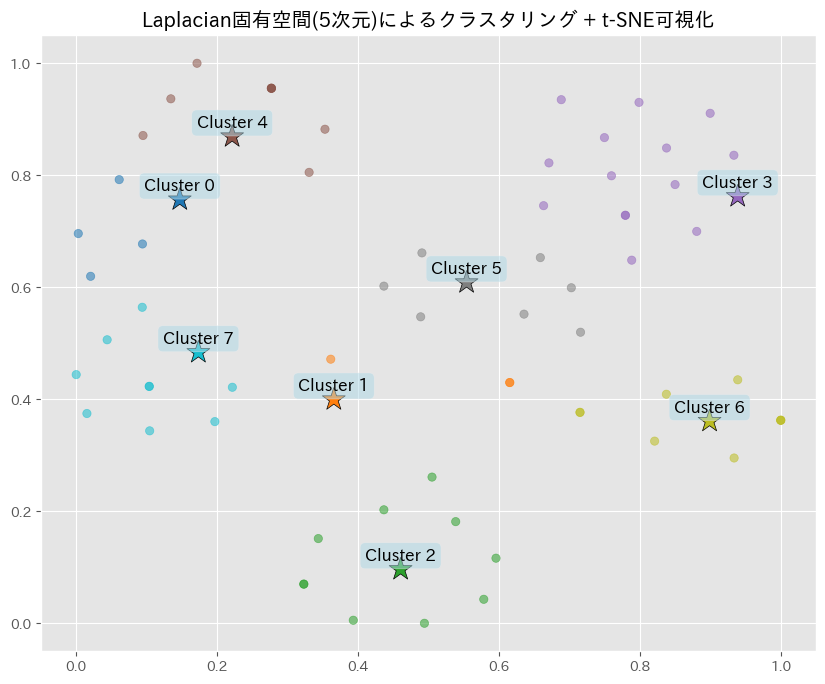


処理完了！ クラスタ件数分布:
cluster
0     6
1     6
2    16
3    15
4    13
5     9
6    10
7    11
Name: count, dtype: int64


In [10]:
# ==============================================================================
# スペクトルクラスタリング（Laplacian固有空間N次元でMクラスター）+ medoid抽出 + t-SNE埋め込み
# ==============================================================================
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.manifold import SpectralEmbedding, TSNE
import matplotlib.pyplot as plt

# （日本語フォントが不要なら下行はコメントアウト可）
try:
    import japanize_matplotlib
except ModuleNotFoundError:
    pass

# --- 1) 分析に使う変数の指定（先頭列＝品番を除外して残り全部） ---
df_cls = df.iloc[:, 1:].copy()

# --- 2) データ型の特定 ---
categorical_features = df_cls.select_dtypes(include=['object', 'category']).columns
numerical_features   = df_cls.select_dtypes(include=np.number).columns

print("質的データ（変換対象）:", categorical_features.tolist())
print("量的データ（正規化対象）:", numerical_features.tolist())

# --- 3) 前処理パイプライン ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)


# --- 4) Laplacian固有ベクトル + クラスタリング + medoid + t-SNE ---
def perform_spectral_embedding_with_medoids(
    dataframe, n_clusters=10, n_components_laplacian=5, flip_x=False, flip_y=False
):
    """
    Laplacian固有ベクトル（次元数を指定）を特徴空間としてクラスタリングを実施。
    t-SNEにより2次元プロットを作成し、クラスタごとのmedoidを描画。
    """
    # 1. 前処理
    X_processed = preprocessor.fit_transform(dataframe)
    X_used = X_processed.toarray() if hasattr(X_processed, "toarray") else np.asarray(X_processed)
    n_samples = X_used.shape[0]

    # 2. スペクトル埋め込み（正規化ラプラシアンの固有ベクトル）
    n_neighbors = min(10, max(2, n_samples - 1))
    embedding = SpectralEmbedding(
        n_components=n_components_laplacian,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        random_state=42
    )
    X_spec = embedding.fit_transform(X_used)  # shape: (n_samples, n_components_laplacian)

    print(f"Laplacian固有空間の形状: {X_spec.shape}")

    # 3. クラスタリング（KMeansでクラスタ数を指定）
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = clusterer.fit_predict(X_spec)

    # 4. medoid計算
    medoid_indices = []
    scores = np.zeros(n_samples)
    for k in range(n_clusters):
        members_idx = np.where(labels == k)[0]
        if len(members_idx) == 0:
            medoid_indices.append(None)
            continue
        members = X_spec[members_idx]
        dist_matrix = pairwise_distances(members)
        medoid_local_idx = np.argmin(dist_matrix.sum(axis=1))
        medoid_idx = members_idx[medoid_local_idx]
        medoid_indices.append(medoid_idx)
        scores[members_idx] = dist_matrix[medoid_local_idx]

    # 5. t-SNE可視化（固有空間から2次元に圧縮）
    perp = min(30, max(5, min(50, n_samples // 3)))
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    X_embedded = tsne.fit_transform(X_spec)

    scaler = MinMaxScaler()
    X_embedded = scaler.fit_transform(X_embedded)

    if flip_x:
        X_embedded[:, 0] = 1 - X_embedded[:, 0]
        print("X軸を反転しました。")
    if flip_y:
        X_embedded[:, 1] = 1 - X_embedded[:, 1]
        print("Y軸を反転しました。")

    # medoid座標
    valid_medoid_idx = [idx for idx in medoid_indices if idx is not None]
    medoid_coords = X_embedded[valid_medoid_idx] if len(valid_medoid_idx) > 0 else np.empty((0, 2))

    # 6. 可視化
    plt.figure(figsize=(10, 8))
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap="tab10", alpha=0.55)
    if len(valid_medoid_idx) > 0:
        plt.scatter(medoid_coords[:, 0], medoid_coords[:, 1],
                    c=range(len(valid_medoid_idx)), cmap="tab10",
                    marker="*", s=300, edgecolor="black")
        for i, (x, y) in enumerate(medoid_coords):
            plt.text(x, y + 0.01, f'Cluster {i}', fontsize=12,
                     ha='center', va='bottom', color='black',
                     bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.5))

    plt.title(f"Laplacian固有空間({n_components_laplacian}次元)によるクラスタリング + t-SNE可視化")
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/ClusterPlot_Lap{n_components_laplacian}_K{n_clusters}.pdf", bbox_inches='tight')
    plt.show()

    # 7. 出力データフレーム
    df_out = dataframe.copy()
    df_out["cluster"] = labels
    df_out["medoid_score"] = scores
    df_out["tsne_x"] = X_embedded[:, 0]
    df_out["tsne_y"] = X_embedded[:, 1]

    return df_out


# --- 5) 実行 ---
#***** 固有ベクトル次元数・クラスタ数の設定
n_components_laplacian = 5   # ← ここを自由に変更可能
num_of_clusters = 8          # ← クラスタ数も別に設定可能

df_medoid = perform_spectral_embedding_with_medoids(
    df_cls,
    n_clusters=num_of_clusters,
    n_components_laplacian=n_components_laplacian,
    flip_x=True,
    flip_y=True
)

print("\n処理完了！ クラスタ件数分布:")
print(df_medoid['cluster'].value_counts().sort_index())


フォントを手動設定しました: Hiragino Sans
重み付け後のデータシェイプ: (86, 6)
Laplacian固有空間の形状: (86, 3)
X軸を反転しました。
Y軸を反転しました。


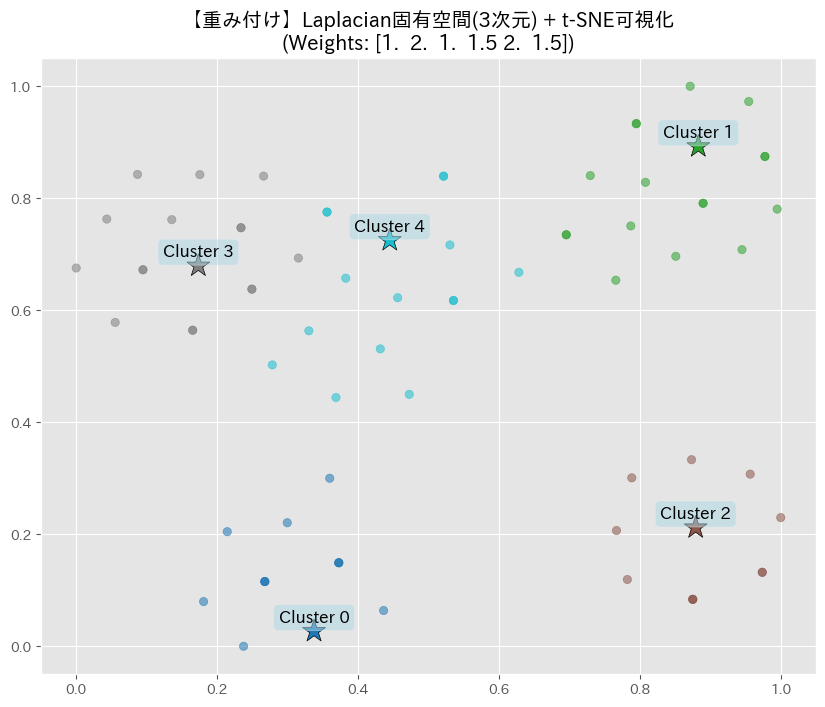


処理完了！ クラスタ件数分布:
cluster
0    16
1    19
2    17
3    17
4    17
Name: count, dtype: int64


In [6]:
# ==============================================================================
# 　【重み付け対応】スペクトルクラスタリング + t-SNE埋め込み
# ==============================================================================
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler # (変更) OneHotEncoder/ColumnTransformer は不要
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.manifold import SpectralEmbedding, TSNE
import matplotlib.pyplot as plt

# (変更) 'japanize_matplotlib' の代わりに 'font_manager' をインポート
from matplotlib import font_manager as fm

# --- ▼ PDF 文字化け対策 ＆ フォントの手動指定 ▼ ---
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42 # (追加) PostScript設定も変更

# (変更) フォントを手動で定義
try:
    font_path = '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc'
    jp_font = fm.FontProperties(fname=font_path)
    # (注：グローバル設定も一応しておく)
    plt.rcParams['font.family'] = jp_font.get_name() 
    print(f"フォントを手動設定しました: {jp_font.get_name()}")
except FileNotFoundError:
    print("エラー: ヒラギノフォントが見つかりません。")
    # (注：ヒラギノが見つからない場合、ダミーのフォントプロパティを設定)
    jp_font = fm.FontProperties(family='sans-serif') 

# --- ▲ ここまで ▲ ---

# （日本語フォントが不要なら下行はコメントアウト可）
try:
     import japanize_matplotlib
except ModuleNotFoundError:
     pass

# --- ▼ PDF 文字化け対策 (この1行を追加) ▼ ---
# plt.rcParams['pdf.fonttype'] = 42

# (注：このスクリプトの前に、df = pd.read_csv(...) が実行されている前提です)

# --- 1) 分析に使う変数の指定 ---
# (変更) iloc[:, 1:] ではなく、'scales' と連動する列名を明示的に指定
target_vars = ["シーズン", "タイプ", "シーン1", "シーン2", "補整力", "シルエット"]
df_cls = df[target_vars].copy() # 元の 'df' から対象列だけをコピー

# --- 2) 定性変数のスコアマッピング (scales) ---
# (注：前回のスクリプトから転記)
scales = {
    "シーズン": {"通年": 3, "夏": 2, "冬": 1},
    "タイプ": {"プチ": 1, "プチ~一般": 2, "一般": 3, "一般~グラマー": 4, "グラマー": 5},
    "シーン1": {"見せない": 1, "見せる": 2},
    "シーン2": {"日中": 1, "all": 2, "就寝": 3},
    "補整力": {},  # 数値そのまま使用
    "シルエット": {"自然": 1, "高さ/自然": 2, "高さ": 3},
}

# --- 3) スコア変換関数 (to_score) ---
# (注： '完全一致' == ロジック)
def to_score(val, mapping):
    """ 'scales' に基づき、単一の値をスコアに変換する """
    val = str(val).strip()
    if not mapping: # '補整力' のような数値コラム
        try:
            return float(val)
        except:
            return np.nan
    # 'scales' の辞書を使って '完全一致' でスコアを取得
    return mapping.get(val, np.nan)

# --- 4) (変更) 前処理パイプラインの代わり ---

# 4-1. 'to_score' を使って全データを数値化
df_scored = pd.DataFrame()
for col in target_vars:
    mapping = scales.get(col, {})
    df_scored[col] = df_cls[col].apply(lambda x: to_score(x, mapping))

# 4-2. スコア化できなかった値（nan）を 0 で埋める
df_scored = df_scored.fillna(0)

# 4-3. スケーリング (StandardScalerを 'df_scored' 全体に適用)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_scored)

# 4-4. (★変更★) 重みの手動設定
# (注：'target_vars' の順序と同じ順序で重みを設定してください)
weights = np.array([
    1.0,  # "シーズン"
    2.0,  # "タイプ" 
    1.0,  # "シーン1"
    1.5,  # "シーン2"
    2.0,  # "補整力" 
    1.5   # "シルエット"
])

# 4-5. 重み付けの適用 (重みの平方根をデータに掛ける)
X_weighted = X_scaled * np.sqrt(weights)

print(f"重み付け後のデータシェイプ: {X_weighted.shape}")


# --- 5) (変更) Laplacian固有ベクトル + クラスタリング + medoid + t-SNE ---
# この関数が本体
def perform_spectral_embedding_with_medoids(
    X_weighted_input, dataframe_original, # (変更) 入力を変更
    n_clusters=10, n_components_laplacian=5, 
    flip_x=False, flip_y=False
):
    """
    (変更) 重み付け済みのデータを入力とし、
    Laplacian固有ベクトル（次元数を指定）を特徴空間としてクラスタリングを実施。
    t-SNEにより2次元プロットを作成し、クラスタごとのmedoidを描画。
    """
    # (変更) 1. 前処理 -> 削除 (既に入力データ 'X_weighted_input' が処理済みのため)
    n_samples = X_weighted_input.shape[0]

    # 2. スペクトル埋め込み（正規化ラプラシアンの固有ベクトル）
    n_neighbors = min(10, max(2, n_samples - 1))
    embedding = SpectralEmbedding(
        n_components=n_components_laplacian,
        affinity="nearest_neighbors", # (注：'precomputed' でAを渡す方法も可)
        n_neighbors=n_neighbors,
        random_state=42
    )
    # (変更) X_used -> X_weighted_input を使用
    X_spec = embedding.fit_transform(X_weighted_input) 
    print(f"Laplacian固有空間の形状: {X_spec.shape}")

    # 3. クラスタリング（KMeansでクラスタ数を指定）
    # (注：クラスタリングは固有空間 'X_spec' で行うので、このロジックは変更不要)
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = clusterer.fit_predict(X_spec)

    # 4. medoid計算
    # (注：medoidも固有空間 'X_spec' で計算するので、変更不要)
    medoid_indices = []
    scores = np.zeros(n_samples)
    for k in range(n_clusters):
        members_idx = np.where(labels == k)[0]
        if len(members_idx) == 0:
            medoid_indices.append(None)
            continue
        members = X_spec[members_idx]
        dist_matrix = pairwise_distances(members)
        medoid_local_idx = np.argmin(dist_matrix.sum(axis=1))
        medoid_idx = members_idx[medoid_local_idx]
        medoid_indices.append(medoid_idx)
        scores[members_idx] = dist_matrix[medoid_local_idx]

    # 5. t-SNE可視化（固有空間から2次元に圧縮）
    # (注：t-SNEも固有空間 'X_spec' で行うので、変更不要)
    perp = min(30, max(5, min(50, n_samples // 3)))
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    X_embedded = tsne.fit_transform(X_spec)

    scaler = MinMaxScaler()
    X_embedded = scaler.fit_transform(X_embedded)

    if flip_x:
        X_embedded[:, 0] = 1 - X_embedded[:, 0]
        print("X軸を反転しました。")
    if flip_y:
        X_embedded[:, 1] = 1 - X_embedded[:, 1]
        print("Y軸を反転しました。")

    valid_medoid_idx = [idx for idx in medoid_indices if idx is not None]
    medoid_coords = X_embedded[valid_medoid_idx] if len(valid_medoid_idx) > 0 else np.empty((0, 2))

    # 6. 可視化 (変更不要)
    plt.figure(figsize=(10, 8))
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap="tab10", alpha=0.55)
    if len(valid_medoid_idx) > 0:
        plt.scatter(medoid_coords[:, 0], medoid_coords[:, 1],
                    c=range(len(valid_medoid_idx)), cmap="tab10",
                    marker="*", s=300, edgecolor="black")
        for i, (x, y) in enumerate(medoid_coords):
            plt.text(x, y + 0.01, f'Cluster {i}', fontsize=12,
                     ha='center', va='bottom', color='black',
                     bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.5))

    plt.title(f"【重み付け】Laplacian固有空間({n_components_laplacian}次元) + t-SNE可視化\n(Weights: {weights})")
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/ClusterPlot_Weighted_Lap{n_components_laplacian}_K{n_clusters}.pdf", bbox_inches='tight')
    plt.show()

    # 7. 出力データフレーム
    # (変更) 'dataframe' -> 'dataframe_original' を使用
    df_out = dataframe_original.copy()
    df_out["cluster"] = labels
    df_out["medoid_score"] = scores
    df_out["tsne_x"] = X_embedded[:, 0]
    df_out["tsne_y"] = X_embedded[:, 1]

    return df_out


# --- 6) (変更) 実行 ---
#***** 固有ベクトル次元数・クラスタ数の設定
n_components_laplacian = 3   # ← ここを自由に変更可能
num_of_clusters = 5          # ← クラスタ数も別に設定可能

# (変更) 呼び出し方を変更
df_medoid = perform_spectral_embedding_with_medoids(
    X_weighted,    # 1. 重み付け済みの数値データ
    df_cls,        # 2. クラスタIDなどを結合するための元のDF
    n_clusters=num_of_clusters,
    n_components_laplacian=n_components_laplacian,
    flip_x=True,
    flip_y=True
)

print("\n処理完了！ クラスタ件数分布:")
print(df_medoid['cluster'].value_counts().sort_index())

In [7]:
df_medoid

,シーズン,タイプ,シーン1,シーン2,補整力,シルエット,cluster,medoid_score,tsne_x,tsne_y
0,夏,一般,見せる,日中,2,自然,2,0.000000e+00,0.879230,0.211924
1,夏,一般,見せる,日中,2,自然,2,9.313226e-10,0.879230,0.211924
2,通年,一般,見せる,日中,3,高さ/自然,4,3.277250e-02,0.521429,0.839543
3,通年,一般,見せる,日中,3,高さ/自然,4,3.277250e-02,0.521429,0.839543
4,夏,一般,見せる,日中,3,高さ/自然,2,1.920756e-02,0.788567,0.300815
...,...,...,...,...,...,...,...,...,...,...
81,通年,一般~グラマー,見せない,日中,2,自然,0,2.874524e-03,0.372716,0.149143
82,通年,一般~グラマー,見せない,日中,2,自然,0,2.874524e-03,0.372716,0.149143
83,通年,一般~グラマー,見せない,日中,2,自然,0,0.000000e+00,0.337603,0.026922
84,通年,一般~グラマー,見せない,日中,2,自然,0,0.000000e+00,0.337603,0.026922


In [8]:
df

,品番,シーズン,タイプ,シーン1,シーン2,補整力,シルエット
0,BT09501,夏,一般,見せる,日中,2,自然
1,BT09503,夏,一般,見せる,日中,2,自然
2,CA525301,通年,一般,見せる,日中,3,高さ/自然
3,CA525104,通年,一般,見せる,日中,3,高さ/自然
4,CA526101,夏,一般,見せる,日中,3,高さ/自然
...,...,...,...,...,...,...,...
81,YH524101,通年,一般~グラマー,見せない,日中,2,自然
82,YH524301,通年,一般~グラマー,見せない,日中,2,自然
83,YH525101,通年,一般~グラマー,見せない,日中,2,自然
84,YH525301,通年,一般~グラマー,見せない,日中,2,自然


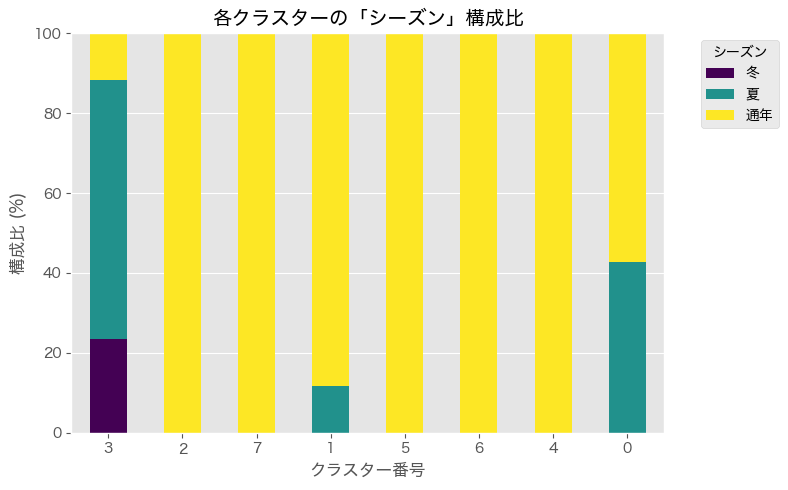

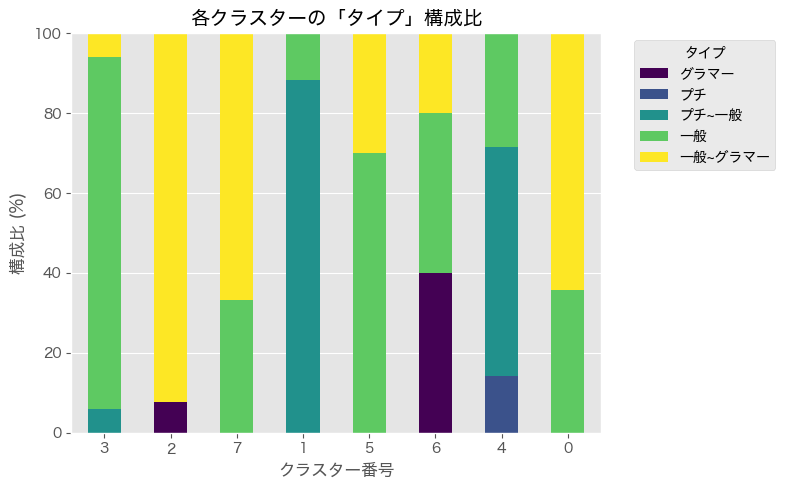

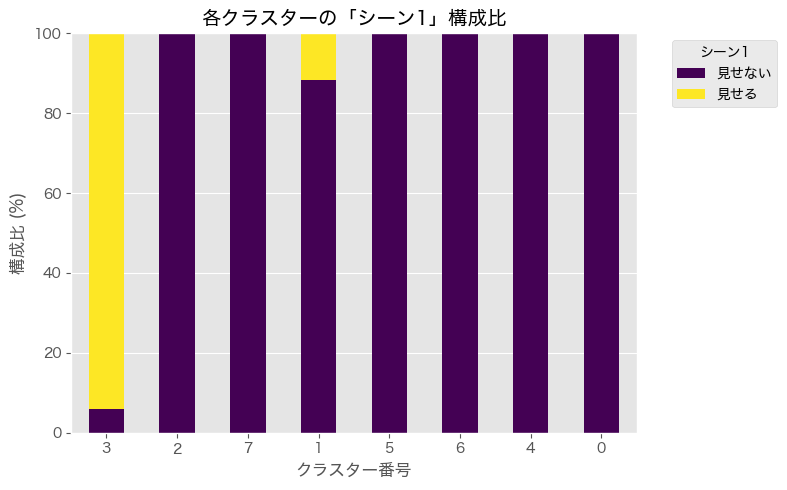

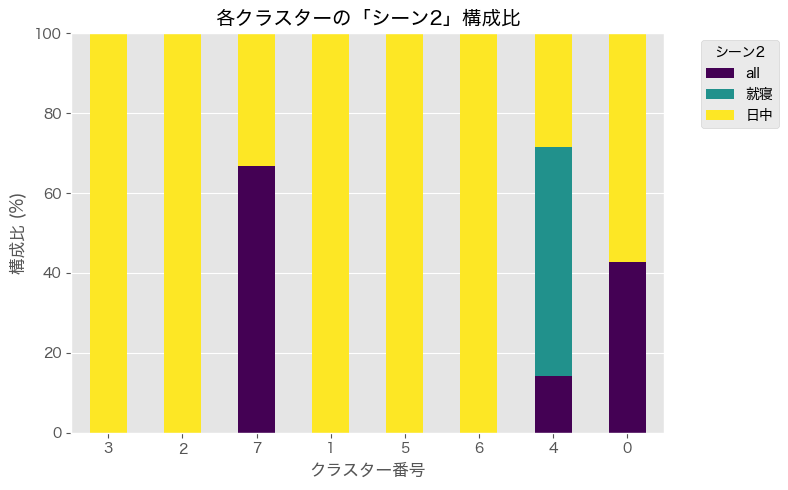

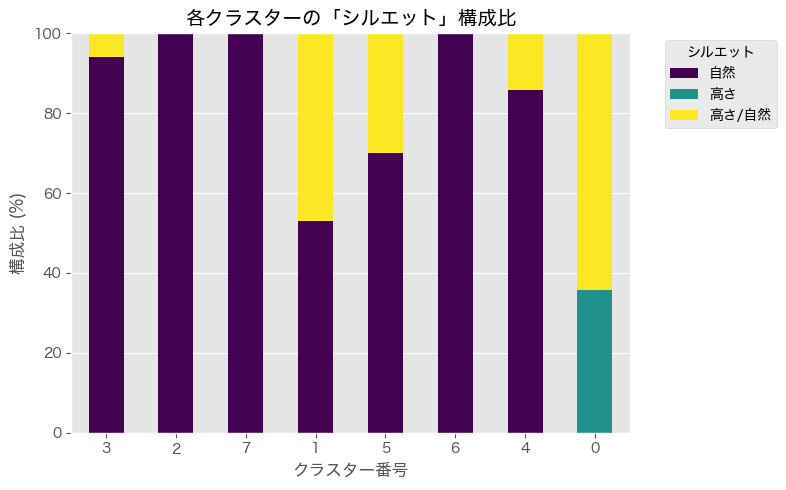

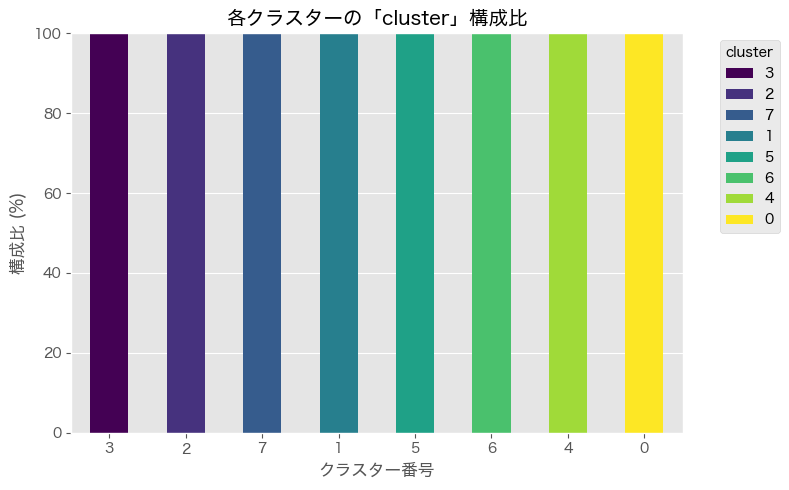


--- 量的変数のグラフ ---


KeyError: "['cluster'] not found in axis"

In [23]:
# ==============================================================================
# クラスター特徴把握　　その2　　積み上げ棒グラフ
# ==============================================================================
import seaborn as sns
import matplotlib.font_manager as fm


# 日本語フォントの設定（ご自身の環境に合わせてコメントを外してパスを指定してください）
font_path = '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc'

# --------------------------------------------------
# メインの処理：全ての質的変数についてグラフを描画
# --------------------------------------------------
# 'cluster'列を除いた質的変数（object型またはcategory型）の列名リストを取得
categorical_cols = df_medoid.select_dtypes(include=['object', 'category']).columns

# ★★★★★★★★★★★★★★★★★
# 任意の順番を指定
#cluster_order = [0,3,2,1,4]
cluster_order = [3,2,7,1,5,6,4,0]
#cluster_order = [9,2,4,11,18,3,1,5,8,10,17,19,14,6,12,16,15,13,7,0]
# ★★★★★★★★★★★★★★★★★

if len(categorical_cols) == 0:
    print("データフレームに質的変数が見つかりませんでした。")
else:
    # 各質的変数についてループ処理
    for col in categorical_cols:
        # クラスターごとの構成比（列方向の合計が100%になるように）を計算
        cross_table_norm = pd.crosstab(df_medoid[col], df_medoid['cluster'], normalize='columns') * 100

        # クロス集計の列を並べ替える
        cross_table_norm = cross_table_norm[cluster_order]
            
        # 積み上げ棒グラフを描画
        ax = cross_table_norm.T.plot(
            kind='bar',
            stacked=True,
            figsize=(8, 5),
            colormap='viridis' # グラフの色合いを変更
        )

        # グラフの体裁を整える
        plt.title(f'各クラスターの「{col}」構成比', fontsize=14)
        plt.ylabel('構成比 (%)', fontsize=12)
        plt.xlabel('クラスター番号', fontsize=12)
        plt.xticks(rotation=0) # X軸のラベル（クラスター番号）を水平に表示
        plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left') # 凡例をグラフの外側に配置
        
        # Y軸の範囲を0%から100%に固定
        plt.ylim(0, 100)
        
        # グラフの周囲の余白を自動調整
        plt.tight_layout()

        #グラフを保存
        plt.savefig(f"./fig/Plot_{col}.png")
        
        # グラフを表示
        plt.show()

# ==============================================================================
# 【追加部分】量的変数のヒストグラム（クラスター別）
# ==============================================================================
print("\n--- 量的変数のグラフ ---")
quantitative_cols = df_medoid.select_dtypes(include=['number', 'float', 'int']).columns.drop('cluster')

if len(quantitative_cols) == 0:
    print("データフレームに量的変数が見つかりませんでした。")
else:
    for col in quantitative_cols:
        plt.figure(figsize=(10, 6))

        df_medoid["cluster"] = pd.Categorical(df_medoid["cluster"], categories=cluster_order, ordered=True)
        
        sns.histplot(
            data=df_medoid,
            x=col,
            hue='cluster',
            hue_order=cluster_order,   # ★ 順序を指定
            palette='viridis',
            kde=True,
            multiple="layer"
        )

        plt.title(f'変数「{col}」のクラスター別分布', fontsize=14)
        plt.xlabel(f'値: {col}', fontsize=12)
        plt.ylabel('度数（件数）', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        plt.savefig(f"./fig/Plot_Numeric{col}.png")
        plt.show()

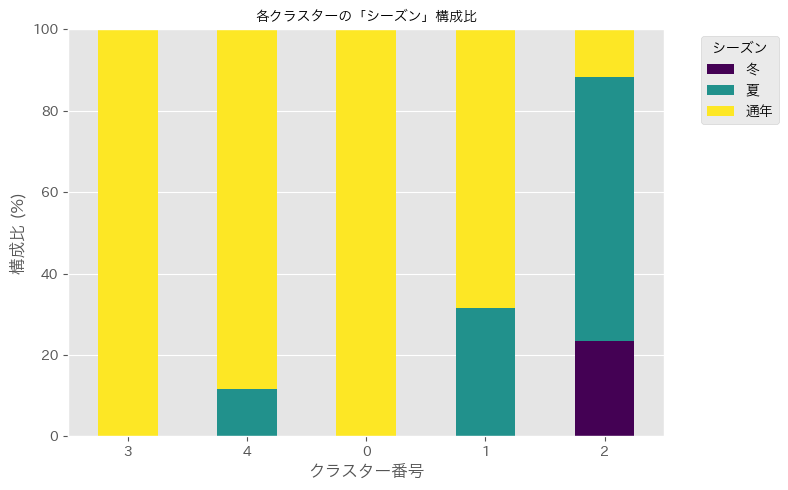

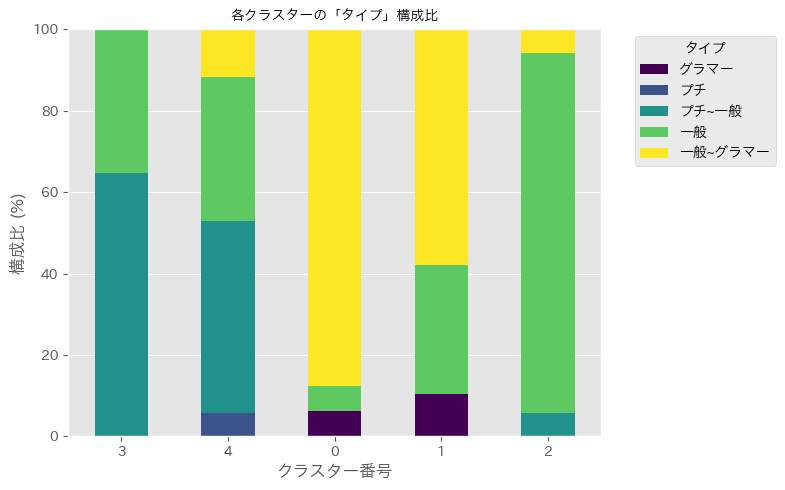

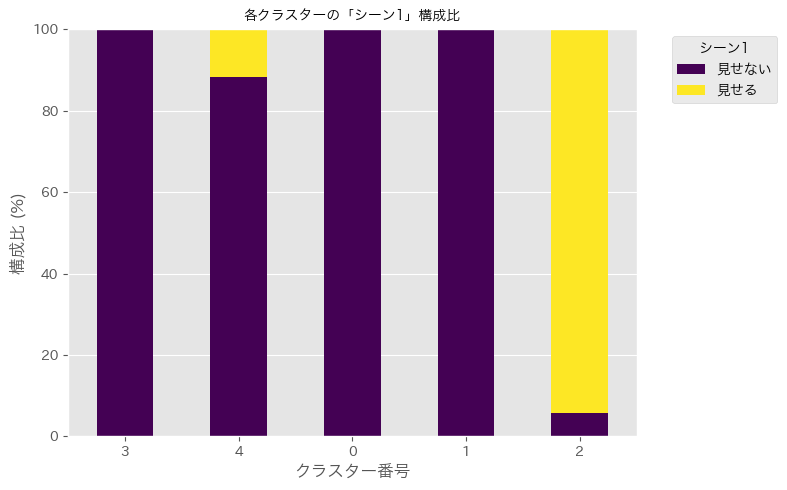

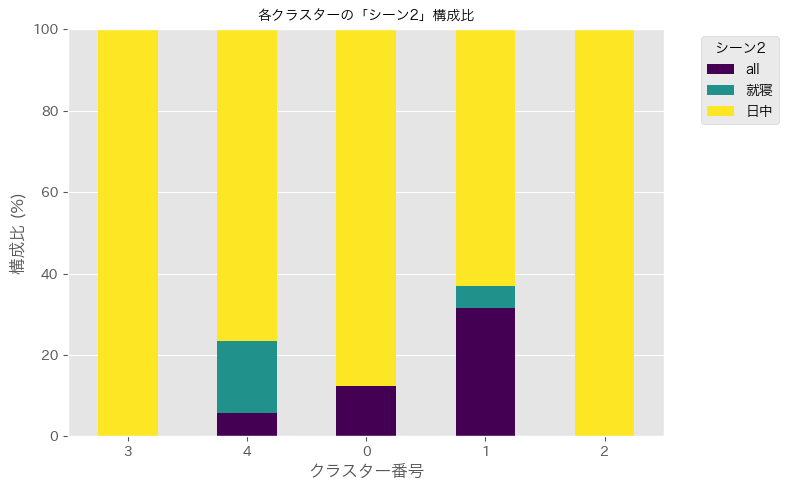

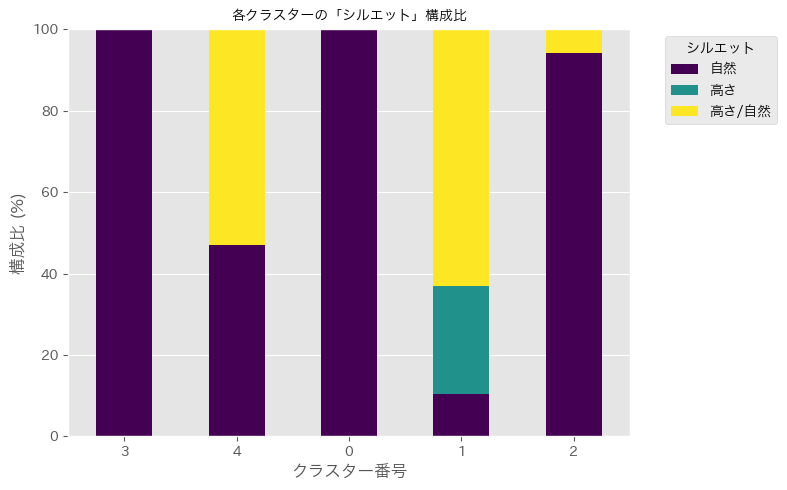


--- 量的変数のグラフ (matplotlib) ---


/var/folders/wd/qvxl37td1wg7gsc7z6cn03t80000gn/T/ipykernel_2986/639328105.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(cluster_order))


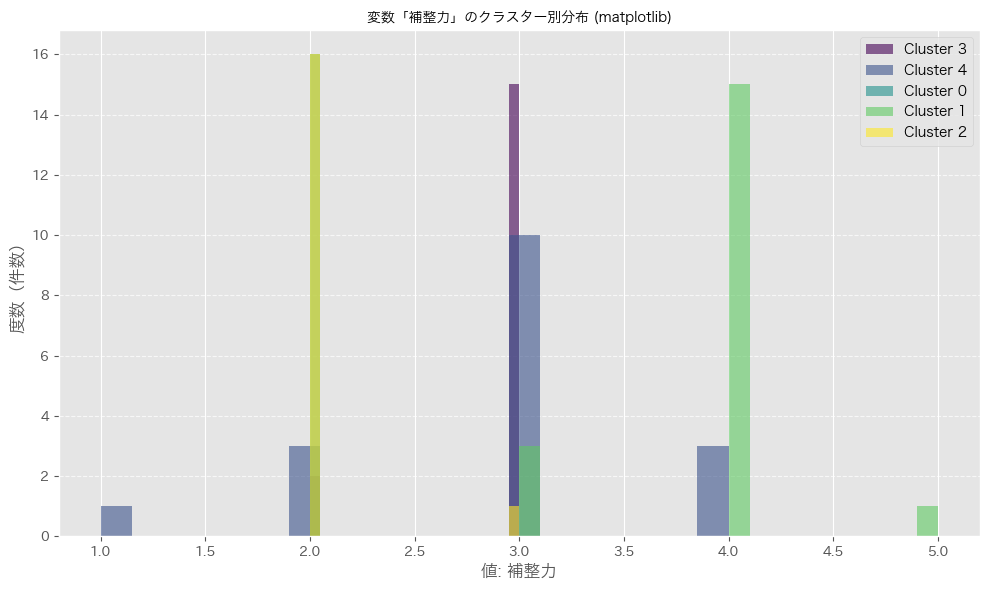

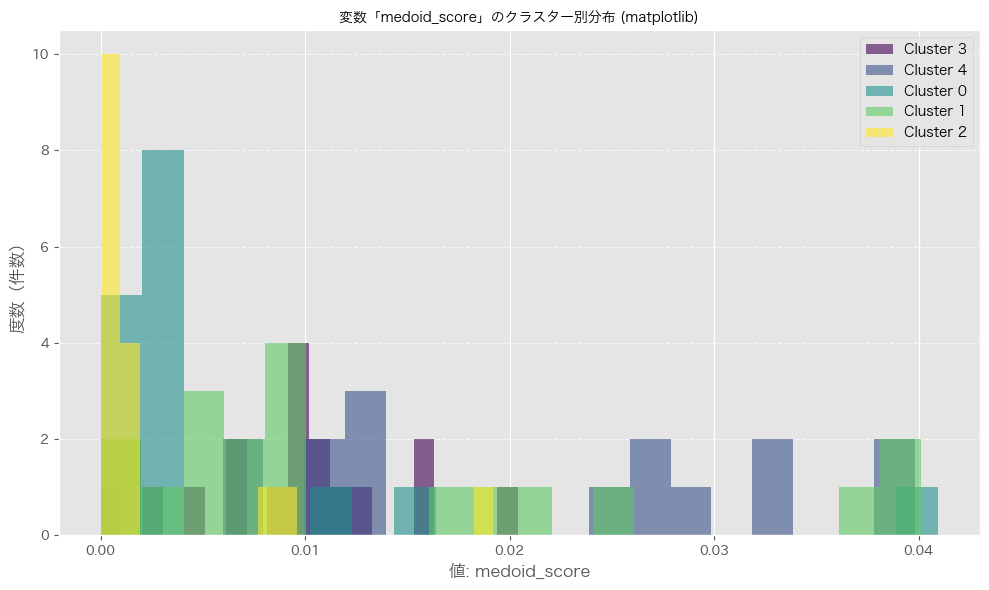

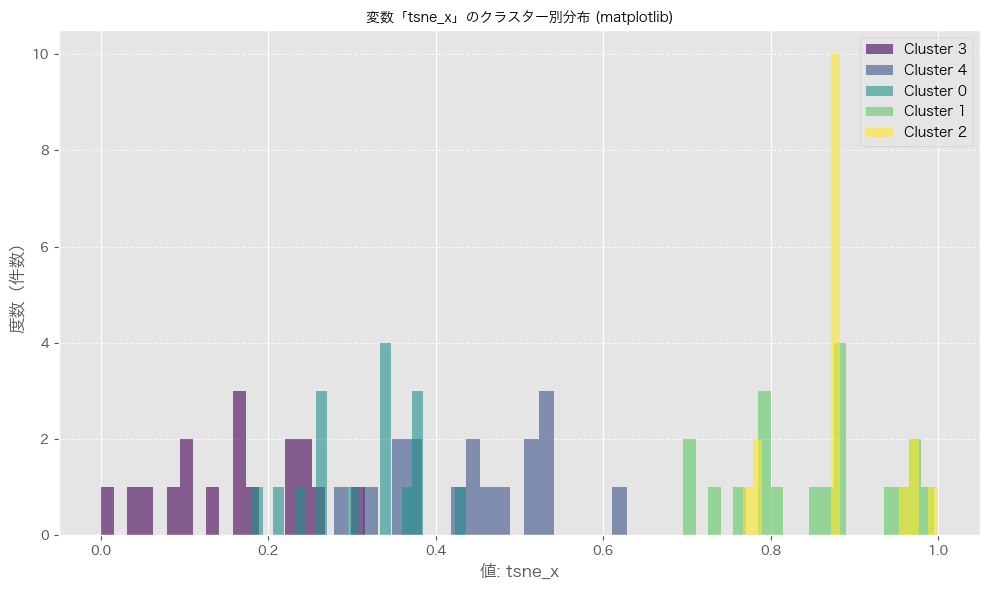

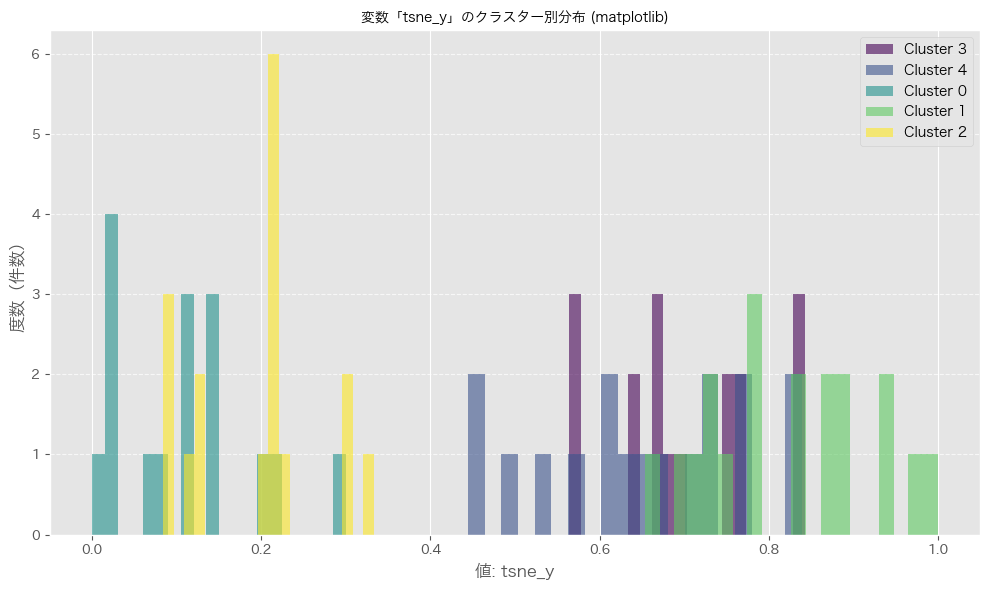

In [9]:
# ==============================================================================
# クラスター特徴把握s
# ==============================================================================
# import seaborn as sns
# import matplotlib.font_manager as fm
# (注：'import matplotlib.pyplot as plt' は、このファイルより前で実行されている前提です)

# --- ▼ PDF 文字化け対策 ＆ フォントの手動指定 ▼ ---
# plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams['ps.fonttype'] = 42

#try:
#    font_path = '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc'
#    jp_font = fm.FontProperties(fname=font_path)
#    print(f"積み上げ棒グラフ: フォントを手動設定しました: {jp_font.get_name()}")
#except FileNotFoundError:
#    print("エラー: ヒラギノフォントが見つかりません。")
#    jp_font = fm.FontProperties(family='sans-serif')
# --- ▲ ここまで ▲ ---


# --- ▼ (追加) Seabornのフォント設定 ▼ ---  <-- ★このブロック全体を削除★
# try:
#     sns.set_theme(font=jp_font.get_name())
#     print(f"Seabornのフォントを '{jp_font.get_name()}' に設定しました。")
# except Exception as e:
#     print(f"Seabornのフォント設定に失敗しました: {e}")
# --- ▲ ここまで ▲ ---


# --------------------------------------------------
# メインの処理：全ての質的変数についてグラフを描画
# --------------------------------------------------
categorical_cols = df_medoid.select_dtypes(include=['object', 'category']).columns

# ★★★★★★★★★★★★★★★★★
cluster_order = [3,4,0,1,2]
# ★★★★★★★★★★★★★★★★★

if len(categorical_cols) == 0:
    print("データフレームに質的変数が見つかりませんでした。")
else:
    for col in categorical_cols:
        cross_table_norm = pd.crosstab(df_medoid[col], df_medoid['cluster'], normalize='columns') * 100
        cross_table_norm = cross_table_norm[cluster_order]
            
        ax = cross_table_norm.T.plot(
            kind='bar',
            stacked=True,
            figsize=(8, 5),
            colormap='viridis'
        )

        plt.title(f'各クラスターの「{col}」構成比', fontsize=14, fontproperties=jp_font) # ★
        plt.ylabel('構成比 (%)', fontsize=12, fontproperties=jp_font) # ★
        plt.xlabel('クラスター番号', fontsize=12, fontproperties=jp_font) # ★
        plt.xticks(rotation=0)
        
        legend = plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.setp(legend.get_title(), fontproperties=jp_font) # ★ 
        for text in legend.get_texts():
            text.set_fontproperties(jp_font) # ★ 
        
        plt.ylim(0, 100)
        plt.tight_layout()
        plt.savefig(f"./fig/Plot_{col}.png")
        plt.show()

# ==============================================================================
# 【追加部分】量的変数のヒストグラム（★Seaborn不使用・matplotlib版★）
# ==============================================================================
print("\n--- 量的変数のグラフ (matplotlib) ---")

# (注：'cluster'が数値でもカテゴリでもエラーにならないよう、
# 　 　'cluster'列を最初から除外してリストを作成します)
all_numeric_cols = df_medoid.select_dtypes(include=['number', 'float', 'int']).columns
quantitative_cols = [col for col in all_numeric_cols if col != 'cluster']

# (注：'cluster'の型をCategoricalに直しておく)
# (この処理はエラー回避のため、ループの外で1回だけ行います)
df_medoid["cluster"] = pd.Categorical(df_medoid["cluster"], categories=cluster_order, ordered=True)

if len(quantitative_cols) == 0:
    print("データフレームに量的変数が見つかりませんでした。")
else:
    # (注：seabornの'viridis'パレットの色を手動で取得します)
    try:
        colors = plt.cm.get_cmap('viridis', len(cluster_order))
    except:
        # matplotlib 3.6以降 'get_cmap' の呼び出し方が変わったため
        colors = plt.colormaps.get_cmap('viridis').resampled(len(cluster_order))

    for col in quantitative_cols:
        plt.figure(figsize=(10, 6))
        
        # (★変更★) 'sns.histplot' の代わりに、クラスターごとに 'plt.hist' でループ
        all_handles = []
        all_labels = []

        for i, cluster_id in enumerate(cluster_order):
            # そのクラスタのデータだけを抽出
            data_subset = df_medoid[df_medoid['cluster'] == cluster_id][col]
            
            if data_subset.empty:
                continue
            
            # (★変更★) plt.hist() で描画
            # 'density=True' にするとKDEのように正規化されますが、
            # 'multiple="layer"' の挙動（重ね描き）を再現するには 'alpha' が必要です
            n, bins, patches = plt.hist(
                data_subset,
                bins=20,          # ビン（棒）の数
                alpha=0.6,        # 透過度 (重ね描きのため)
                label=f'Cluster {cluster_id}', # 凡例ラベル
                color=colors(i),  # 色を指定
                density=False     # 'False'で度数（件数）
            )
            # (注：KDE（曲線）は 'scipy' がないと描画が難しいため、ここでは省略しています)

        plt.title(f'変数「{col}」のクラスター別分布 (matplotlib)', fontsize=14, fontproperties=jp_font)
        plt.xlabel(f'値: {col}', fontsize=12, fontproperties=jp_font)
        plt.ylabel('度数（件数）', fontsize=12, fontproperties=jp_font)
        
        # (★変更★) 凡例の手動設定
        legend = plt.legend() # plt.hist で付けた 'label' を基に凡例を作成
        if legend is not None: 
            plt.setp(legend.get_title(), fontproperties=jp_font)
            for text in legend.get_texts():
                text.set_fontproperties(jp_font)

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        plt.savefig(f"./fig/Plot_Numeric{col}.png")
        plt.show()

In [10]:
print("cross_table_norm.columns:", cross_table_norm.columns)
print("cluster_order:", cluster_order)
pd.crosstab(df_medoid['補整力'],df_medoid['cluster'],dropna=False)


cross_table_norm.columns: Index([3, 4, 0, 1, 2], dtype='int32', name='cluster')
cluster_order: [3, 4, 0, 1, 2]


cluster,3,4,0,1,2
補整力,,,,,
1,0,1,0,0,0
2,2,3,16,0,16
3,15,10,0,3,1
4,0,3,0,15,0
5,0,0,0,1,0


In [11]:
pd.crosstab(df_medoid['シルエット'],df_medoid['cluster'],dropna=False)

cluster,3,4,0,1,2
シルエット,,,,,
自然,17,8,16,2,16
高さ,0,0,0,5,0
高さ/自然,0,9,0,12,1


In [12]:
# ==============================================================================
# 　JSONファイルの書き出し
# ==============================================================================
import pandas as pd
import json

#品番名を最初の列として加える
# col1=df_original.iloc[:,[0]]
col1=df_original[df_original["ワイヤー"] == "なし"].iloc[:,[0]]
df_result = pd.concat([col1,df_medoid],axis=1)

def export_medoid_json(df_result, output_path="./data/df_medoid.json"):
    nodes = []

    # ★★★★★★★★★★★★★★★★★
    #代表を幾つまで書き出すか
    cls_rep = 10
    # 以下にあるように、強制的に全てを代表にした。つまりRep=1にした
    # ★★★★★★★★★★★★★★★★★
    
    # 各クラスタごとに medoid_score が小さい順に2件のインデックスを取得
    medoid_indices = (
        df_result.groupby("cluster", observed=False)["medoid_score"]
        .apply(lambda x: x.nsmallest(cls_rep).index)
        .explode()
        .values
    )

    for idx, row in df_result.iterrows():
        node = {
            "id": str(row["品番"]),
            "icon": f"images/{row['品番']}.jpg",
            "x": float(2000 * row["tsne_x"] ),
            "y": float(1480 * -row["tsne_y"] ),
           # "x": row["tsne_x"] ,
           # "y": row["tsne_y"] ,
           # "Rep": 1 if idx in medoid_indices else 0,   # 代表なら1
            "Rep": 1,
            "cluster": int(row["cluster"])
        }
        nodes.append(node)

    data = {
        "nodes": nodes,
        "links": []  # 今回はリンクなし
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"全データ {len(nodes)} 件を書き出しました。代表点は {len(medoid_indices)} 件です。")

# ★★★★★★★★★★★★★★★★★
# 実行例
export_medoid_json(df_result, "./data/20251104_NonWire_3-5.json")
# ★★★★★★★★★★★★★★★★★

全データ 86 件を書き出しました。代表点は 50 件です。


In [13]:
# ★★★★★ CSV出力を追加 ★★★★★
csv_path = "./data/csv/20251104_NonWire_3-5.csv"
df_result.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"CSVファイルも出力しました → {csv_path}")


CSVファイルも出力しました → ./data/csv/20251104_NonWire_3-5.csv


In [ ]:
# =============================================================================
# 　クラスター別レーダーチャート作成スクリプト（日本語フォント指定版）
# =============================================================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager as fm

# --- ① ファイルパスを指定 ---------------------------------------------------
file_path = "../data/20251104_NonWire_4-6.csv"  # 同じフォルダにある場合

# --- ② CSVを読み込み ---------------------------------------------------------
df = pd.read_csv(file_path)

# --- ③ 対象変数 --------------------------------------------------------------
target_vars = ["シーズン", "タイプ", "シーン1", "シーン2", "補整力", "シルエット"]

# --- ④ 定性変数のスコアマッピング ------------------------------------------
scales = {
    "シーズン": {"通年": 3, "夏": 2, "冬": 2, "春": 1, "秋": 1},
    "タイプ": {"プチ~一般": 1, "一般": 2, "一般~グラマー": 3, "グラマー": 4},
    "シーン1": {"見せない": 1, "見せる": 2},
    "シーン2": {"日中": 1, "all": 2, "夜": 3},
    "補整力": {},  # 数値そのまま使用
    "シルエット": {"自然": 1, "高さ/自然": 2, "高さ": 3},
}

# --- ⑤ スコア変換関数 -------------------------------------------------------
def to_score(row, col):
    """文字列をスコア化する"""
    val = str(row[col])
    mapping = scales[col]
    if mapping:
        for k, v in mapping.items():
            if k in val:
                return v
    try:
        return float(val)
    except:
        return 0

# --- ⑥ クラスターごとの中央値スコアを計算 ----------------------------------
radar_data = []
for cluster_id, group in df.groupby("cluster"):
    scores = [np.median([to_score(r, col) for _, r in group.iterrows()]) for col in target_vars]
    radar_data.append((cluster_id, scores))

# --- ⑦ 日本語フォント設定 ----------------------------------------------------
font_path = '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc'
jp_font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = jp_font.get_name()

# =============================================================================
# 　（セクション①〜⑦は元のスクリプトと同じ）
# =============================================================================

# (追加) スクリプトの一番上（import pandas as pd の下など）に以下を記述してください
import os

# --- ⑧ レーダーチャート描画 (スコア表示追加) --------------------------
labels = target_vars
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # 最初と最後を繋げるため

# 保存先のフォルダを指定
output_folder = "./charts_output" 
# 保存先フォルダが存在しない場合は自動で作成する
os.makedirs(output_folder, exist_ok=True)

# 保存したファイル名を記録するリスト
saved_files = []

# クラスターごとにループ処理
for cluster_id, scores in radar_data:
    
    # クラスターごとに新しいFigureを作成
    plt.figure(figsize=(8, 8))
    
    # polar=TrueのAxes（プロット領域）を明示的に作成
    ax = plt.subplot(111, polar=True)

    # データを準備（最初と最後を繋げる）
    stats = scores + scores[:1]
    
    # 線をプロット
    ax.plot(angles, stats, label=f"Cluster {cluster_id}")
    # 内側を塗りつぶし
    ax.fill(angles, stats, alpha=0.25)

    # (変更) Y軸の最大値を取得し、テキスト表示のオフセットとY軸の描画範囲を調整
    max_score = np.max(scores)
    if max_score == 0: # 全て0だとオフセットが0になるのを防ぐ
        text_offset = 0.5 
        ylim_max = 1.0
    else:
        text_offset = max_score * 0.1 # 最大スコアの10%くらいをオフセットにする
        ylim_max = max_score + text_offset * 2 # テキストがはみ出ないようY軸の上限を広げる
        
    ax.set_ylim(0, ylim_max) 

    # (追加) 各頂点にスコアの数値を表示
    # scores（N個）と angles[:-1]（N個）を使ってテキストを配置
    for angle, score in zip(angles[:-1], scores):
        ax.text(
            angle,              # 角度
            score + text_offset, # 表示位置（スコアより少し外側）
            f"{score:.1f}",     # 表示するテキスト（小数点以下1桁にフォーマット）
            ha='center',        # 水平位置（中央寄せ）
            va='bottom',        # 垂直位置（テキストの「下」をプロット位置に合わせる）
            fontsize=10,
            fontproperties=jp_font # 日本語フォント指定
        )

    # 軸ラベル（項目名）を設定。フォントも指定
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontproperties=jp_font, fontsize=12)
    
    # グラフのタイトルを設定。フォントも指定
    ax.set_title(
        f"クラスター {cluster_id} のレーダーチャート（特徴7変数）", 
        fontsize=14, 
        fontproperties=jp_font,
        pad=20 # タイトルがグラフに重ならないように調整
    )
    
    # Y軸（値）のラベルが見やすいように調整
    ax.tick_params(axis='y', labelsize=10)
    ax.set_rlabel_position(22.5) # ラベルの位置を少しずらす

    # レイアウトを自動調整
    plt.tight_layout()

    # --- ⑨ 図を保存 (ループ内に変更) -------------------------------------------
    
    # (変更) ファイル名に "_with_scores" を追加
    base_filename = f"ClusterRadar_mac_fontpath_C{cluster_id}_with_scores.png"
    
    # os.path.joinで、保存先フォルダとファイル名を結合
    save_filename = os.path.join(output_folder, base_filename)
    
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    
    # 図を表示
    plt.show()
    
    # メモリを解放するためにFigureを閉じる
    plt.close()
    
    saved_files.append(save_filename)

# (変更) 最後にまとめて保存ファイル名を出力
print(f"✅ 以下のレーダーチャート（スコア付）を '{output_folder}' フォルダに保存しました：")
for f in saved_files:
    print(f"  - {f}")

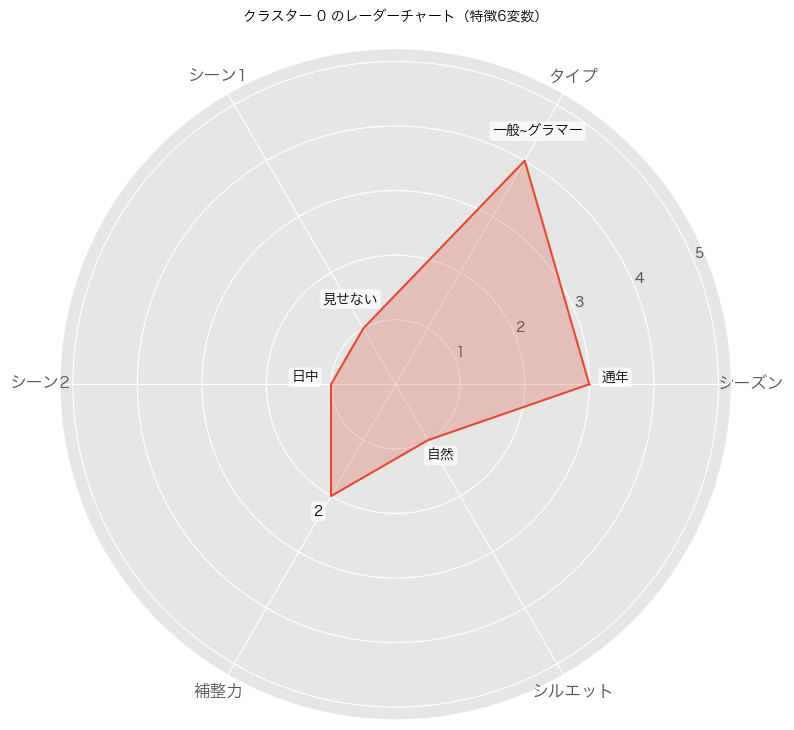

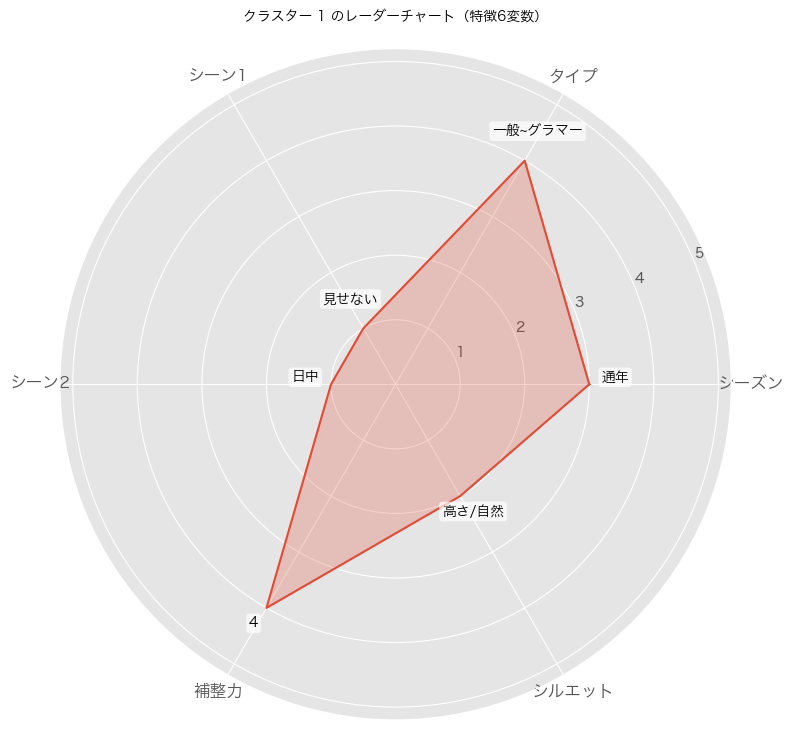

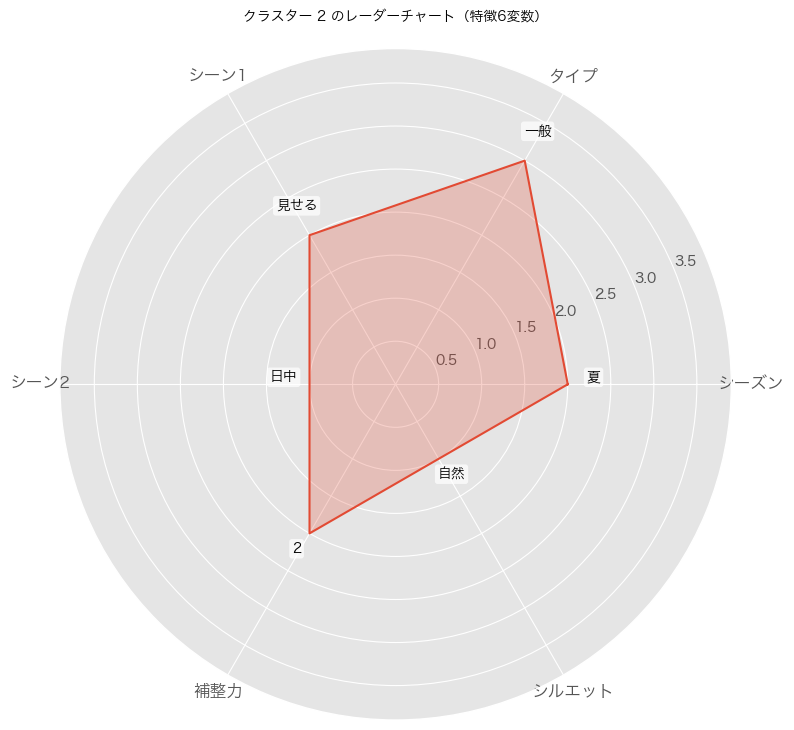

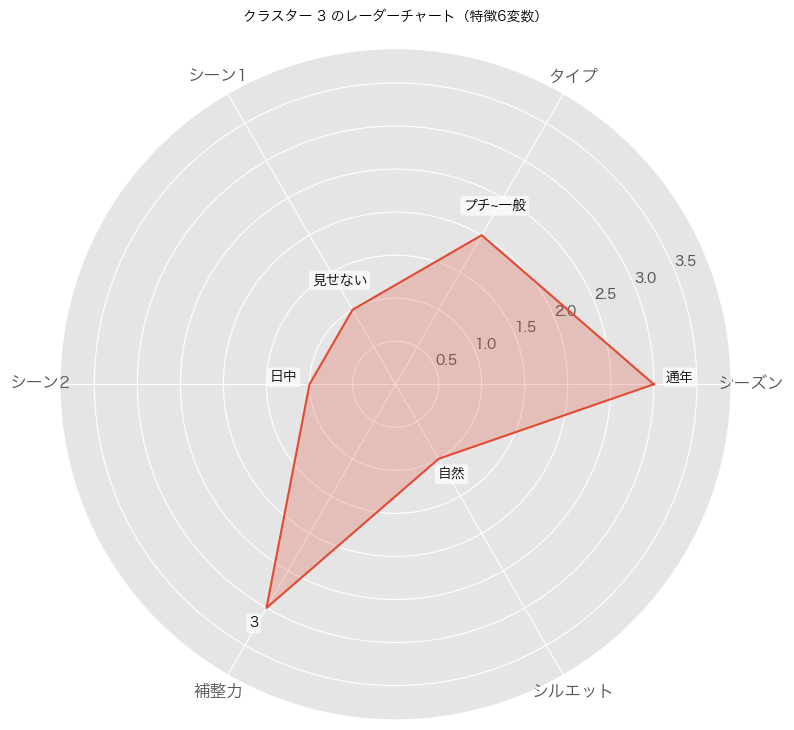

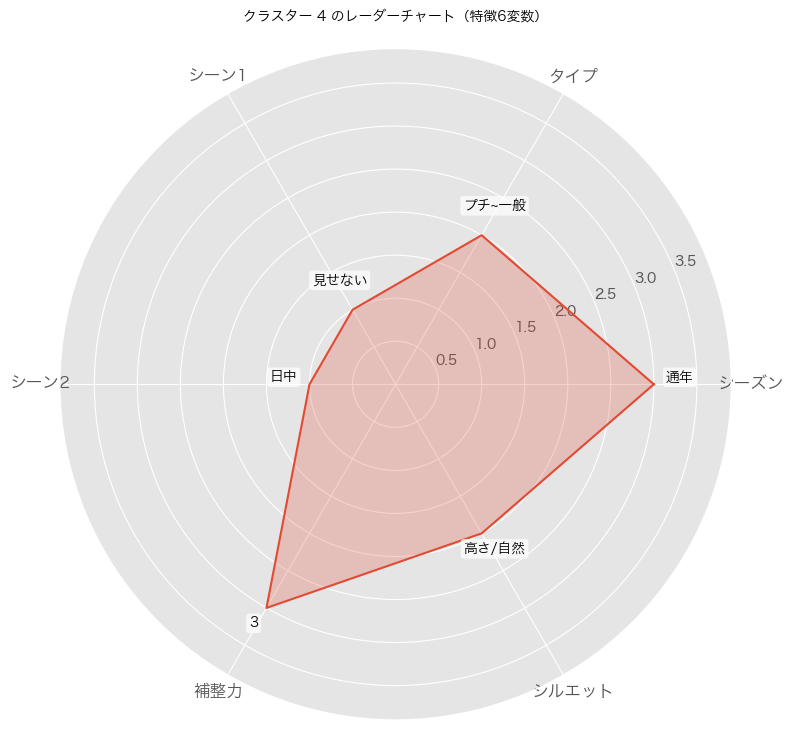

✅ 以下のレーダーチャート（完全一致・最頻値ラベル付）を './charts_output' フォルダに保存しました：
  - ./charts_output/ClusterRadar_mac_fontpath_C0_with_labels.png
  - ./charts_output/ClusterRadar_mac_fontpath_C1_with_labels.png
  - ./charts_output/ClusterRadar_mac_fontpath_C2_with_labels.png
  - ./charts_output/ClusterRadar_mac_fontpath_C3_with_labels.png
  - ./charts_output/ClusterRadar_mac_fontpath_C4_with_labels.png


In [61]:
# =============================================================================
# 　クラスター別レーダーチャート作成スクリプト（完全一致・最頻値ラベル表示版）
# =============================================================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager as fm

# --- ① ファイルパスを指定 ---------------------------------------------------
file_path = "./data/20251104_NonWire_3-5.csv" 

# --- ② CSVを読み込み ---------------------------------------------------------
df = pd.read_csv(file_path)

# --- ③ 対象変数 --------------------------------------------------------------
target_vars = ["シーズン", "タイプ", "シーン1", "シーン2", "補整力", "シルエット"]

# --- ④ 定性変数のスコアマッピング (変更：ご提示の新しい scales) --------------
scales = {
    "シーズン": {"通年": 3, "夏": 2, "冬": 1},
    "タイプ": {"プチ": 1, "プチ~一般": 2, "一般": 3, "一般~グラマー": 4,"グラマー": 5,}, 
    "シーン1": {"見せない": 1, "見せる": 2},
    "シーン2": {"all": 2, "日中": 1, "就寝": 3}, # "夜" から "就寝" に変更
    "補整力": {},  # 数値そのまま使用
    "シルエット": {"自然": 1,"高さ/自然": 2, "高さ": 3},
}


# --- ⑤ スコア変換関数 ( '完全一致' == ロジック) ------------------------------
def to_score(row, col):
    """文字列をスコア化する"""
    # .strip() を使い、CSV内の " 一般 " のような前後の空白を削除
    val = str(row[col]).strip() 
    
    mapping = scales[col]
    
    # 補整力など、マッピングが空（数値）の場合
    if not mapping:
        try:
            return float(val)
        except:
            return np.nan # 数値に変換できない場合はnan
            
    # .get(val, np.nan) は、
    # 「もし val が mapping のキーに存在したら、その値(v)を返す」
    # 「もし存在しなかったら、np.nan を返す」
    return mapping.get(val, np.nan)

# --- ⑥ クラスターごとの中央値スコアと「最頻値の文字列」を計算 --------------
radar_data = []

for cluster_id, group in df.groupby("cluster"):
    
    median_scores = [] # グラフの「位置」を決めるためのスコア
    mode_strings = []  # グラフに「表示」するためのカテゴリ名
    
    for col in target_vars:
        
        # 1. スコア（数値）のリストを作成し、中央値を計算
        scores_series = group.apply(lambda r: to_score(r, col), axis=1)
        median_scores.append(np.nanmedian(scores_series))
        
        # 2. 元の文字列（str型）のリストを作成し、最頻値（mode）を計算
        strings_series = group[col].astype(str)
        
        mode_val = strings_series.mode() 
        
        if not mode_val.empty:
            # .strip() を追加し、表示するラベルも空白を除去
            mode_strings.append(mode_val[0].strip())
        else:
            mode_strings.append("N/A") 

    radar_data.append((cluster_id, median_scores, mode_strings))

# --- ⑦ 日本語フォント設定 ----------------------------------------------------
font_path = '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc'
jp_font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = jp_font.get_name()

# --- ⑧ レーダーチャート描画 (最頻値ラベル表示) -----------------------------
labels = target_vars
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # 最初と最後を繋げるため

output_folder = "./charts_output" 
os.makedirs(output_folder, exist_ok=True)
saved_files = []

for cluster_id, scores, label_strings in radar_data:
    
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    stats = scores + scores[:1]
    ax.plot(angles, stats, label=f"Cluster {cluster_id}")
    ax.fill(angles, stats, alpha=0.25)

    max_score = np.nanmax(scores) 
    if max_score == 0 or np.isnan(max_score):
        text_offset = 0.5 
        ylim_max = 1.0
    else:
        text_offset = max_score * 0.1 
        ylim_max = max_score + text_offset * 3 
        
    ax.set_ylim(0, ylim_max) 

    # 各頂点に「最頻値の文字列」を表示
    for angle, score, label_str in zip(angles[:-1], scores, label_strings):
        
        if np.isnan(score):
            continue
            
        ax.text(
            angle,              
            score + text_offset, 
            label_str,           # カテゴリ名（例：「夏」）を表示
            ha='center',        
            va='bottom',        
            fontsize=10,
            fontproperties=jp_font, 
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec='none', alpha=0.7)
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontproperties=jp_font, fontsize=12)
    
    ax.set_title(
        f"クラスター {cluster_id} のレーダーチャート（特徴{num_vars}変数）", 
        fontsize=14, 
        fontproperties=jp_font,
        pad=20 
    )
    
    ax.tick_params(axis='y', labelsize=10)
    ax.set_rlabel_position(22.5) 

    plt.tight_layout()

    # --- ⑨ 図を保存 (ループ内に変更) -------------------------------------------
    
    base_filename = f"ClusterRadar_mac_fontpath_C{cluster_id}_with_labels.png"
    save_filename = os.path.join(output_folder, base_filename)
    
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    saved_files.append(save_filename)

print(f"✅ 以下のレーダーチャート（完全一致・最頻値ラベル付）を '{output_folder}' フォルダに保存しました：")
for f in saved_files:
    print(f"  - {f}")

## 🖼️　以下は個別ファイルで独立に動作するファイル

In [14]:
df_original

,品番,写真,名前,ブランド名,チャネル,上代,年度,会期月,シーズン,ステップ,...,シーン2,補整力,シルエット,Shop_初速3か月（月割）,Shop_初速3か月（平均）,EC_初速3か月（月割）,EC_初速3か月（平均）,Shop&EC_初速3か月（月割）,Sho&EC_初速3か月（平均）,上代数値
0,BT09501,BT09501.jpg,パテッドブラ,FIT,店舗・EC,"6,000",2026SS,2026年3月,夏,なし,...,日中,2,自然,0,0,0,0,0,0,6000
1,BT09503,BT09503.jpg,チュールブラキャミ,FIT,店舗・EC,"7,500",2026SS,2026年3月,夏,なし,...,日中,2,自然,0,0,0,0,0,0,7500
2,CA525301,CA525301.jpg,ﾌﾞﾗﾃﾞﾘｽ ﾚｰｼｨﾌﾞﾗﾄｯﾌﾟ25A1,NY,店舗・EC,"7,500",2025AW,2025年7月,通年,0,...,日中,3,高さ/自然,585,195,75,37,660,232,7500
3,CA525104,CA525104.jpg,ﾌﾞﾗﾃﾞﾘｽ ﾚｰｼｨﾌﾞﾗｷｬﾐ25S1,NY,店舗・EC,"7,200",2025SS,2025年3月,通年,0,...,日中,3,高さ/自然,522,174,86,28,608,202,7200
4,CA526101,CA526101.jpg,ﾌﾞﾗﾃﾞﾘｽ ﾚｰｼｨﾌﾞﾗｷｬﾐ26S1,NY,店舗・EC,"8,000",2026SS,2026年3月,夏,0,...,日中,3,高さ/自然,0,0,0,0,0,0,8000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,YH524101,YH524101.jpg,ゆきねえﾓｱｿﾌﾄ快適ﾊﾞｽﾄﾎｰﾙﾄﾞｼｪｲﾌﾟﾌﾞﾗｷｬﾐ24,Yukine. Inc.,テレビ・EC,"5,200",2024AW,2024年5月,通年,なし,...,日中,2,自然,NaN,NaN,794,264,804,267,5200
82,YH524301,YH524301.jpg,ゆきねえ365綿混ﾓｱらく快適ﾌﾙｶｯﾌﾟﾌﾞﾗｷｬﾐ24,Yukine. Inc.,テレビ・EC,"4,600",2024AW,2024年9月,通年,なし,...,日中,2,自然,NaN,NaN,616,205,0,0,4600
83,YH525101,YH525101.jpg,ゆきねえﾓｱｿﾌﾄ快適ﾌﾙｶｯﾌﾟﾌﾞﾗｷｬﾐ25,Yukine. Inc.,テレビ・EC,"5,200",2025SS,2025年5月,通年,なし,...,日中,2,自然,NaN,NaN,"1,523",507,0,0,5200
84,YH525301,YH525301.jpg,ゆきねえ365綿混ﾓｱらく快適ﾌﾙｶｯﾌﾟﾌﾞﾗｷｬﾐ25,Yukine. Inc.,テレビ・EC,"5,200",2025SS,2025年10月,通年,なし,...,日中,2,自然,NaN,NaN,0,0,0,0,5200


In [21]:
# ===============================================
# 全体売上（Shop+EC)のデータをマージする
#  ファイルから読み込む
# ===============================================
import os 
import pandas as pd
import json

in_file1 = '../data/csv/20251104_NonWire.csv'  # 元のファイル
df1 = pd.read_csv(in_file1, encoding="utf-8")
in_file2 = "../data/csv/20251104_NonWire_3-5.csv"   # 5クラスターのデータを読み込む
df2 = pd.read_csv(in_file2, encoding="utf-8")


In [22]:
df1

,品番,写真,名前,ブランド名,チャネル,上代,年度,会期月,シーズン,ステップ,...,シーン1,シーン2,補整力,シルエット,Shop_初速3か月（月割）,Shop_初速3か月（平均）,EC_初速3か月（月割）,EC_初速3か月（平均）,Shop&EC_初速3か月（月割）,Sho&EC_初速3か月（平均）
0,BT09501,BT09501.jpg,パテッドブラ,FIT,店舗・EC,"6,000",2026SS,2026年3月,夏,なし,...,見せる,日中,2,自然,0,0,0,0,0,0
1,BT09503,BT09503.jpg,チュールブラキャミ,FIT,店舗・EC,"7,500",2026SS,2026年3月,夏,なし,...,見せる,日中,2,自然,0,0,0,0,0,0
2,CA525301,CA525301.jpg,ﾌﾞﾗﾃﾞﾘｽ ﾚｰｼｨﾌﾞﾗﾄｯﾌﾟ25A1,NY,店舗・EC,"7,500",2025AW,2025年7月,通年,0,...,見せる,日中,3,高さ/自然,585,195,75,37,660,232
3,CA525104,CA525104.jpg,ﾌﾞﾗﾃﾞﾘｽ ﾚｰｼｨﾌﾞﾗｷｬﾐ25S1,NY,店舗・EC,"7,200",2025SS,2025年3月,通年,0,...,見せる,日中,3,高さ/自然,522,174,86,28,608,202
4,CA526101,CA526101.jpg,ﾌﾞﾗﾃﾞﾘｽ ﾚｰｼｨﾌﾞﾗｷｬﾐ26S1,NY,店舗・EC,"8,000",2026SS,2026年3月,夏,0,...,見せる,日中,3,高さ/自然,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,YH524101,YH524101.jpg,ゆきねえﾓｱｿﾌﾄ快適ﾊﾞｽﾄﾎｰﾙﾄﾞｼｪｲﾌﾟﾌﾞﾗｷｬﾐ24,Yukine. Inc.,テレビ・EC,"5,200",2024AW,2024年5月,通年,なし,...,見せない,日中,2,自然,NaN,NaN,794,264,804,267
82,YH524301,YH524301.jpg,ゆきねえ365綿混ﾓｱらく快適ﾌﾙｶｯﾌﾟﾌﾞﾗｷｬﾐ24,Yukine. Inc.,テレビ・EC,"4,600",2024AW,2024年9月,通年,なし,...,見せない,日中,2,自然,NaN,NaN,616,205,0,0
83,YH525101,YH525101.jpg,ゆきねえﾓｱｿﾌﾄ快適ﾌﾙｶｯﾌﾟﾌﾞﾗｷｬﾐ25,Yukine. Inc.,テレビ・EC,"5,200",2025SS,2025年5月,通年,なし,...,見せない,日中,2,自然,NaN,NaN,"1,523",507,0,0
84,YH525301,YH525301.jpg,ゆきねえ365綿混ﾓｱらく快適ﾌﾙｶｯﾌﾟﾌﾞﾗｷｬﾐ25,Yukine. Inc.,テレビ・EC,"5,200",2025SS,2025年10月,通年,なし,...,見せない,日中,2,自然,NaN,NaN,0,0,0,0


In [23]:
df2

,品番,シーズン,タイプ,シーン1,シーン2,補整力,シルエット,cluster,medoid_score,tsne_x,tsne_y
0,BT09501,夏,一般,見せる,日中,2,自然,2,0.000000e+00,0.879230,0.211924
1,BT09503,夏,一般,見せる,日中,2,自然,2,9.313226e-10,0.879230,0.211924
2,CA525301,通年,一般,見せる,日中,3,高さ/自然,4,3.277250e-02,0.521429,0.839543
3,CA525104,通年,一般,見せる,日中,3,高さ/自然,4,3.277250e-02,0.521429,0.839543
4,CA526101,夏,一般,見せる,日中,3,高さ/自然,2,1.920756e-02,0.788567,0.300815
...,...,...,...,...,...,...,...,...,...,...,...
81,YH524101,通年,一般~グラマー,見せない,日中,2,自然,0,2.874524e-03,0.372716,0.149143
82,YH524301,通年,一般~グラマー,見せない,日中,2,自然,0,2.874524e-03,0.372716,0.149143
83,YH525101,通年,一般~グラマー,見せない,日中,2,自然,0,0.000000e+00,0.337603,0.026922
84,YH525301,通年,一般~グラマー,見せない,日中,2,自然,0,0.000000e+00,0.337603,0.026922


In [24]:

# 途中にある重複した列を除く
df2 = df2.iloc[:,[0]+list(range(7,11))]

# df1とdf2とを結合する
df_merged = pd.merge(df1,df2,how='left',on='品番')


In [ ]:
df_merged

In [27]:

#出来上がったCSVファイルを確認の為にアウトプットする
out_file = "../data/csv/20251104_NonWire_3-5-ShopEc売上付.csv"
df_merged.to_csv(out_file, index=False, encoding="utf-8-sig")


In [30]:
in_file = "../data/csv/20251104_NonWire_3-5-ShopEc売上付.csv"  
df1 = pd.read_csv(in_file, encoding="utf-8")


In [35]:
in_file = "../data/csv/20251104-shop_List.csv"  
df2 = pd.read_csv(in_file, encoding="utf-8")


In [36]:
df2

,品番,店舗展開
0,ME122105,1
1,ME124304,1
2,ME123102,1
3,ME525101,1
4,ME123103,1
5,ME125301,1
6,ME522301,1
7,ME125302,1
8,ME124303,1
9,ME125101,1


In [37]:

df = pd.merge(df1,df2,how='left',on='品番')

In [40]:
#出来上がったCSVファイルを確認の為にアウトプットする
out_file = "../data/csv/20251104_NonWire_3-5-ShopEc売上付02.csv"
df.to_csv(out_file, index=False, encoding="utf-8-sig")

In [5]:
# ==============================================================================
# 以下は独立ファイルです。
# ファイルを読み込んでのJSONファイル変換（独立して動作可能）
# ==============================================================================
import pandas as pd
import json

# ===============================================================
# （1）保存しておいた df ファイルの読み込み
# ===============================================================
# 例：CSVファイル名をここで指定
input_file =  "../data/csv/20251104_NonWire_3-5-ShopEc売上付02.csv"  # 必要に応じて変更
df_result = pd.read_csv(input_file, encoding="utf-8")


# 売上枚数をすべて数値型にする
df_result.iloc[:, 21:27] = (
    df_result.iloc[:, 21:27]
    .replace(',', '', regex=True)  # カンマを削除
    .apply(pd.to_numeric, errors='coerce')  # 数値型(float)に変換
)

# df_result

# ===============================================================
# JSON書き出し関数
# ===============================================================
def export_medoid_json(df_result, target_col='' ,output_path="./data/df_medoid.json"):
 
    # --- 数値変換（カンマを除去しながら） ---
    df_result[target_col] = (
        df_result[target_col]
        .replace(',', '', regex=True)
        .apply(pd.to_numeric, errors='coerce')
    )
   
    # 新しい列 'top10' を作成
    df_result['top10'] = 0  # 初期化（すべて0）
    # 上位10件のインデックスを取得
    top10_index = df_result[target_col].nlargest(10).index
    # 対応する行に1を代入
    df_result.loc[top10_index, 'top10'] = 1
    
    nodes = []

    for idx, row in df_result.iterrows():
        # Rep列が存在し、値が1の場合は1、それ以外は0
        # rep_value = int(row["Rep"]) if "Rep" in df_result.columns and row["Rep"] == 1 else 0
        # 全てを画像表示する為に　強制的にRep=1とした
        # rep_value = 1
        rep_value = row['top10']
        
        # ✅ 店舗展開のNaNを0に置換
        is_in_store = 0 if pd.isna(row.get('店舗展開')) else row['店舗展開']

        # ✅ 数値変換（文字列でも整数化できるようにする）
        try:
            is_in_store = int(float(is_in_store))
        except (ValueError, TypeError):
            is_in_store = 0
        
        node = {
            "id": str(row["品番"]),
            "icon": f"images/{row['品番']}.jpg",
            "x": float(2000 * row["tsne_x"]),
            "y": float(1480 * -row["tsne_y"]),
            "Rep": rep_value,
            "cluster": int(row["cluster"]),
            "IniSpeed1": int(row[target_col]) if pd.notna(row[target_col]) else 0,
            "Brand":str(row["ブランド名"]),
            "IsInStore":is_in_store
        }
        nodes.append(node)

    data = {
        "nodes": nodes,
        "links": []  # 今回はリンクなし
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2, allow_nan=False)

    rep_count = sum(1 for n in nodes if n["Rep"] == 1)
    print(f"✅ JSON書き出し完了: {len(nodes)} 件（代表点 {rep_count} 件）")
    print(f"保存先: {output_path}")

# ===============================================================
# 実行
# ===============================================================

# 店舗の売り上げ枚数の円を表示する為のデータ
export_medoid_json(df_result, 'Shop_初速3か月（月割）', "../data/20251104_NonWire_3-5-Shop.json")
out_file = "../data/csv/20251104_NonWire_3-5-Shop.csv"
df_result.to_csv(out_file, index=False, encoding="utf-8-sig")

# ECの売り上げ枚数の円を表示する為のデータ
export_medoid_json(df_result, 'EC_初速3か月（月割）', "../data/20251104_NonWire_3-5-EC.json")
out_file = "../data/csv/20251104_NonWire_3-5-EC.csv"
df_result.to_csv(out_file, index=False, encoding="utf-8-sig")

✅ JSON書き出し完了: 86 件（代表点 10 件）
保存先: ../data/20251104_NonWire_3-5-Shop.json
✅ JSON書き出し完了: 86 件（代表点 10 件）
保存先: ../data/20251104_NonWire_3-5-EC.json


/var/folders/wd/qvxl37td1wg7gsc7z6cn03t80000gn/T/ipykernel_57968/434157138.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(',', '', regex=True)
/var/folders/wd/qvxl37td1wg7gsc7z6cn03t80000gn/T/ipykernel_57968/434157138.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(',', '', regex=True)


In [4]:
df_result.dtypes

品番                    object
店舗展開                 float64
写真                    object
名前                    object
cluster                int64
medoid_score         float64
tsne_x               float64
tsne_y               float64
ブランド名                 object
チャネル                  object
上代                    object
年度                    object
会期月                   object
シーズン                  object
ステップ                  object
ワイヤー                  object
タイプ                   object
シーン1                  object
シーン2                  object
補整力                    int64
シルエット                 object
Shop_初速3か月（月割）        object
Shop_初速3か月（平均）        object
EC_初速3か月（月割）          object
EC_初速3か月（平均）          object
Shop&EC_初速3か月（月割）     object
Sho&EC_初速3か月（平均）      object
dtype: object

In [2]:
pd.crosstab(df_result['ブランド名'],df_result['cluster'],dropna=False)

cluster,0,1,2,3,4
ブランド名,,,,,
FIT,0,0,2,0,0
MAGIC,2,2,7,0,3
Me,2,13,6,1,8
NY,0,2,1,0,2
PEACE,2,2,1,16,4
Yukine. Inc.,10,0,0,0,0


In [3]:
# 店舗展開=1 のデータを抽出
df_InShop = df_result[df_result['店舗展開'] == 1].iloc[:, [0, 4, 21, 23]]

# 合計値を計算
shop_sum = df_InShop.iloc[:, 2].sum()
ec_sum   = df_InShop.iloc[:, 3].sum()

# 各行を合計比率に変換
df_InShop['Shop_比率'] = df_InShop.iloc[:, 2] / shop_sum * 100
df_InShop['EC_比率']   = df_InShop.iloc[:, 3] / ec_sum * 100

df_InShop.sort_values(by='cluster')

,品番,cluster,Shop_初速3か月（月割）,EC_初速3か月（月割）,Shop_比率,EC_比率
43,ME124304,0,3508.0,766.0,11.86177,4.073601
48,ME125303,0,0.0,0.0,0.0,0.0
44,ME125101,1,896.0,359.0,3.029688,1.909168
53,ME522301,1,1544.0,1302.0,5.220802,6.924059
40,ME124301,1,420.0,75.0,1.420166,0.398851
39,ME124103,1,263.0,480.0,0.889295,2.552648
38,ME123103,1,1771.0,1159.0,5.988368,6.163582
37,ME123102,1,2950.0,3524.0,9.974978,18.740693
34,ME09502,1,0.0,0.0,0.0,0.0
36,ME122105,1,6693.0,6059.0,22.631365,32.221868


In [19]:

# === cluster ごとに平均を計算 ===
df_cluster_sum = (
    df_InShop
    .groupby('cluster')[['Shop_比率', 'EC_比率']]
    .sum()
    .reset_index()
)

# 結果確認
df_cluster_sum

,cluster,Shop_比率,EC_比率
0,0,11.86177,4.073601
1,1,57.100832,73.409913
2,2,10.894705,8.168475
3,3,1.511463,1.106148
4,4,18.63123,13.241863


In [110]:
df_result[df_result['初速3か月（月割）'] != 0] \
    .groupby('cluster')['初速3か月（月割）'] \
    .count()

cluster
0    2
1    3
2    3
3    5
4    1
5    6
6    4
7    6
8    2
Name: 初速3か月（月割）, dtype: int64

In [6]:
import pandas as pd

# --- 例として df_result が与えられているとする ---
# 非数値列のすべての値を確認する

def list_non_numeric_values(df):
    # 数値型でない列を抽出
    non_numeric_cols = df.select_dtypes(exclude=['number']).columns

    # 各列ごとにユニーク値を列挙
    for col in non_numeric_cols:
        unique_vals = df[col].dropna().unique()  # NaNを除外してユニーク値を抽出
        print(f"\n📊 列名: {col}")
        print(f"値の種類: {len(unique_vals)} 件")
        print(unique_vals)

# --- 実行 ---
list_non_numeric_values(df_result)


📊 列名: 品番
値の種類: 86 件
['BT09501' 'BT09503' 'CA525301' 'CA525104' 'CA526101' 'CA126106'
 'CA126115' 'DB12417' 'DB12420' 'DB124201' 'DB124202' 'DB12422' 'DB12424'
 'DB124302' 'DB125101' 'DB125102' 'DB125103' 'DB125202' 'DB125203'
 'DB125401' 'DB524201' 'DB524203' 'DB525101' 'DB525102' 'DB525103'
 'DB525104' 'DB525202' 'DB525204' 'DB525207' 'DB525301' 'DB525404'
 'DB525406' 'ME06601' 'ME08503' 'ME09502' 'ME118307' 'ME122105' 'ME123102'
 'ME123103' 'ME124103' 'ME124301' 'ME124302' 'ME124303' 'ME124304'
 'ME125101' 'ME125102' 'ME125301' 'ME125302' 'ME125303' 'ME126101'
 'ME126103' 'ME126104' 'ME518306' 'ME522301' 'ME524301' 'ME524302'
 'ME525101' 'ME525301' 'ME525303' 'ME525304' 'ME525305' 'ME526101'
 'MG02503' 'MG07501' 'MG07502' 'MG07504' 'MG07505' 'MG122201' 'MG124301'
 'MG125201' 'MG125301' 'MG523101' 'MG525401' 'MG525402' 'MG525403'
 'MG525404' 'YH09501' 'YH124201' 'YH124301' 'YH125201' 'YH125401'
 'YH524101' 'YH524301' 'YH525101' 'YH525301' 'YH525401']

📊 列名: 写真
値の種類: 86 件
['BT09501.jp

In [8]:
df_result.dtypes

品番                    object
店舗展開                 float64
写真                    object
名前                    object
cluster                int64
medoid_score         float64
tsne_x               float64
tsne_y               float64
ブランド名                 object
チャネル                  object
上代                    object
年度                    object
会期月                   object
シーズン                  object
ステップ                  object
ワイヤー                  object
タイプ                   object
シーン1                  object
シーン2                  object
補整力                    int64
シルエット                 object
Shop_初速3か月（月割）       float64
Shop_初速3か月（平均）        object
EC_初速3か月（月割）         float64
EC_初速3か月（平均）          object
Shop&EC_初速3か月（月割）     object
Sho&EC_初速3か月（平均）      object
top10                  int64
dtype: object